In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import seaborn as sns
import fastf1 as f1
from fastf1 import plotting
from ing_theme_matplotlib import mpl_style
import mplcyberpunk

In [2]:
def convert_to_normal(time):
    if pd.isna(time):
        return time

    time_str = str(time)
    parts = time_str.split()

    days = int(parts[0])
    minutes, seconds_with_microseconds = parts[2].split(":")[1:]
    seconds, microseconds = seconds_with_microseconds.split(".")

    minutes = int(minutes)
    seconds = int(seconds)
    microseconds = int(microseconds)

    total_microseconds = (
        days * 86400000000 + minutes * 60000000 + seconds * 1000000 + microseconds
    )

    minutes, remaining_microseconds = divmod(total_microseconds, 60000000)
    seconds, microseconds = divmod(remaining_microseconds, 1000000)

    normal_time = f"{minutes:02d}:{seconds:02d}.{microseconds:06d}"
    return normal_time

*Sprint Qualifying*

In [3]:
SpQuali = f1.get_session(2026, "Miami", "Sprint Qualifying")
SpQuali.load()

req         WARNING 	DEFAULT CACHE ENABLED! (1.14 GB) /home/hexa/.cache/fastf1


core           INFO 	Loading data for Miami Grand Prix - Sprint Qualifying [v3.8.1]


req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info


core        WARNING 	Sprint Qualifying is not supported by Ergast! Limited results are calculated from timing data.


...

req            INFO 	Using cached data for car_data


req            INFO 	Using cached data for position_data


req            INFO 	Using cached data for weather_data


req            INFO 	Using cached data for race_control_messages


core           INFO 	Finished loading data for 22 drivers: ['1', '12', '81', '16', '3', '63', '44', '43', '6', '10', '5', '27', '87', '23', '55', '41', '30', '31', '11', '77', '14', '18']


In [4]:
SpQuali.session_info

{'Meeting': {'Key': 1284,
  'Name': 'Miami Grand Prix',
  'OfficialName': 'FORMULA 1 CRYPTO.COM MIAMI GRAND PRIX 2026',
  'Location': 'Miami Gardens',
  'Number': 6,
  'Country': {'Key': 19, 'Code': 'USA', 'Name': 'United States'},
  'Circuit': {'Key': 151, 'ShortName': 'Miami'}},
 'SessionStatus': 'Inactive',
 'ArchiveStatus': {'Status': 'Generating'},
 'Key': 11271,
 'Type': 'Qualifying',
 'Name': 'Sprint Qualifying',
 'StartDate': datetime.datetime(2026, 5, 1, 16, 30),
 'EndDate': datetime.datetime(2026, 5, 1, 17, 14),
 'GmtOffset': datetime.timedelta(days=-1, seconds=72000),
 'Path': '2026/2026-05-03_Miami_Grand_Prix/2026-05-01_Sprint_Qualifying/'}

In [5]:
SpQuali.results.loc[
    :, ["Abbreviation", "TeamName", "GridPosition", "Position", "Time", "Status"]
]

,Abbreviation,TeamName,GridPosition,Position,Time,Status
1,NOR,McLaren,NaN,1.0,NaT,
12,ANT,Mercedes,NaN,2.0,NaT,
81,PIA,McLaren,NaN,3.0,NaT,
16,LEC,Ferrari,NaN,4.0,NaT,
3,VER,Red Bull Racing,NaN,5.0,NaT,
63,RUS,Mercedes,NaN,6.0,NaT,
44,HAM,Ferrari,NaN,7.0,NaT,
43,COL,Alpine,NaN,8.0,NaT,
6,HAD,Red Bull Racing,NaN,9.0,NaT,
10,GAS,Alpine,NaN,10.0,NaT,


In [6]:
SpQuali_laps = SpQuali.laps
SpQuali_laps

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:15:59.631000,LEC,16,NaT,1.0,1.0,0 days 00:13:57.759000,NaT,NaT,0 days 00:00:43.210000,...,True,Ferrari,0 days 00:13:57.759000,2026-05-01 20:32:17.762,1,NaN,False,,False,False
1,0 days 00:17:28.921000,LEC,16,0 days 00:01:29.290000,2.0,1.0,NaT,NaT,0 days 00:00:30.401000,0 days 00:00:33.839000,...,True,Ferrari,0 days 00:15:59.631000,2026-05-01 20:34:19.634,12,NaN,False,,False,True
2,0 days 00:19:29.656000,LEC,16,0 days 00:02:00.735000,3.0,1.0,NaT,NaT,0 days 00:00:42.075000,0 days 00:00:44.329000,...,True,Ferrari,0 days 00:17:28.921000,2026-05-01 20:35:48.924,1,NaN,False,,False,True
3,0 days 00:21:33.044000,LEC,16,0 days 00:02:03.388000,4.0,1.0,NaT,NaT,0 days 00:00:45.733000,0 days 00:00:47.413000,...,True,Ferrari,0 days 00:19:29.656000,2026-05-01 20:37:49.659,12,NaN,True,DOUBLE YELLOW AT TURN 19,False,True
4,0 days 00:23:01.777000,LEC,16,0 days 00:01:28.733000,5.0,1.0,NaT,NaT,0 days 00:00:30.318000,0 days 00:00:33.566000,...,True,Ferrari,0 days 00:21:33.044000,2026-05-01 20:39:53.047,1,NaN,False,,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,0 days 00:40:34.606000,LIN,41,0 days 00:01:30.573000,8.0,3.0,NaT,NaT,0 days 00:00:31.118000,0 days 00:00:34.308000,...,True,Racing Bulls,0 days 00:39:04.033000,2026-05-01 20:57:24.036,1,NaN,False,,False,True
233,0 days 00:43:15.594000,LIN,41,0 days 00:02:40.988000,9.0,3.0,NaT,0 days 00:42:27.027000,0 days 00:00:39.678000,0 days 00:00:41.724000,...,True,Racing Bulls,0 days 00:40:34.606000,2026-05-01 20:58:54.609,1,NaN,False,,False,False
234,0 days 00:15:07.130000,STR,18,NaT,1.0,1.0,0 days 00:13:06.309000,NaT,NaT,0 days 00:00:43.862000,...,True,Aston Martin,0 days 00:13:06.309000,2026-05-01 20:31:26.312,1,NaN,False,,False,False
235,0 days 00:17:16.212000,STR,18,0 days 00:02:09.082000,2.0,1.0,NaT,NaT,0 days 00:00:32.282000,0 days 00:00:34.870000,...,True,Aston Martin,0 days 00:15:07.130000,2026-05-01 20:33:27.133,12,NaN,True,TRACK LIMITS AT TURN 5 LAP 3,False,True


In [7]:
nor_SpQuali_laps = SpQuali.laps.pick_driver("NOR")
fastest_lap_nor_SpQuali = nor_SpQuali_laps.pick_fastest().LapTime
nor_SpQuali_lap_time = nor_SpQuali_laps["LapTime"]
nor_SpQuali_sec1 = nor_SpQuali_laps["Sector1Time"]
nor_SpQuali_sec2 = nor_SpQuali_laps["Sector2Time"]
nor_SpQuali_sec3 = nor_SpQuali_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(fastest_lap_nor_SpQuali), "which was in Lap number" ,nor_SpQuali_laps.pick_fastest().LapNumber)
nor_SpQuali_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:27.869000 which was in Lap number 14.0


/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
82,NaT,NaT,0 days 00:00:42.714000,0 days 00:00:29.465000,177.0,152.0,251.0,265.0
83,0 days 00:01:39.706000,0 days 00:00:30.647000,0 days 00:00:33.764000,0 days 00:00:35.295000,220.0,192.0,186.0,128.0
84,0 days 00:02:01.158000,0 days 00:00:45.383000,0 days 00:00:43.551000,0 days 00:00:32.224000,157.0,141.0,256.0,261.0
85,0 days 00:01:28.723000,0 days 00:00:30.179000,0 days 00:00:33.615000,0 days 00:00:24.929000,222.0,190.0,262.0,320.0
86,0 days 00:02:12.839000,0 days 00:00:43.060000,0 days 00:00:47.713000,0 days 00:00:42.066000,152.0,86.0,258.0,153.0


In [8]:
fastest_lap_nor_SpQuali = nor_SpQuali_laps.pick_fastest()
tele_nor_SpQuali = fastest_lap_nor_SpQuali.get_telemetry().add_distance()
speed_nor_SpQuali = tele_nor_SpQuali.Speed
tele_nor_SpQuali.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,272.673368,0,11478.492557
3,274.000000,0,11576.000000
4,277.125001,0,11707.250048
5,279.000000,0,11786.000000
6,281.395835,0,11788.875002
...,...,...,...
648,264.974999,0,11114.562445
649,265.000000,0,11116.000000
650,265.468749,0,11155.843648
651,266.000000,0,11201.000000


In [9]:
ant_SpQuali_laps = SpQuali.laps.pick_driver("ANT")
fastest_lap_ant_SpQuali = ant_SpQuali_laps.pick_fastest().LapTime
ant_SpQuali_lap_time = ant_SpQuali_laps["LapTime"]
ant_SpQuali_sec1 = ant_SpQuali_laps["Sector1Time"]
ant_SpQuali_sec2 = ant_SpQuali_laps["Sector2Time"]
ant_SpQuali_sec3 = ant_SpQuali_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(fastest_lap_ant_SpQuali), "which was in Lap number" ,ant_SpQuali_laps.pick_fastest().LapNumber)
ant_SpQuali_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:28.091000 which was in Lap number 13.0


/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
53,NaT,NaT,0 days 00:00:47.889000,0 days 00:00:37.674000,187.0,61.0,260.0,157.0
54,0 days 00:01:29.312000,0 days 00:00:30.537000,0 days 00:00:33.702000,0 days 00:00:25.073000,221.0,189.0,265.0,324.0
55,0 days 00:02:11.239000,0 days 00:00:46.254000,0 days 00:00:43.460000,0 days 00:00:41.525000,147.0,124.0,NaN,252.0
56,NaT,0 days 00:01:06.254000,0 days 00:00:48.607000,0 days 00:00:47.700000,185.0,106.0,249.0,176.0
57,0 days 00:01:56.298000,0 days 00:00:34.756000,0 days 00:00:44.908000,0 days 00:00:36.634000,168.0,165.0,NaN,274.0


In [10]:
fastest_lap_ant_SpQuali = ant_SpQuali_laps.pick_fastest()
tele_ant_SpQuali = fastest_lap_ant_SpQuali.get_telemetry().add_distance()
speed_ant_SpQuali = tele_ant_SpQuali.Speed
tele_ant_SpQuali.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,272.499999,7,10596.624986
3,275.499996,7,10630.374957
4,276.000000,7,10636.000000
5,279.000000,7,10777.000000
6,280.624998,7,10834.687443
...,...,...,...
662,269.188888,7,10376.411061
663,270.744444,7,10486.855505
664,271.000000,7,10505.000000
665,271.764285,7,10497.357147


In [11]:
lec_SpQuali_laps = SpQuali.laps.pick_driver("LEC")
fastest_lap_lec_SpQuali = lec_SpQuali_laps.pick_fastest().LapTime
lec_SpQuali_lap_time = lec_SpQuali_laps["LapTime"]
lec_SpQuali_sec1 = lec_SpQuali_laps["Sector1Time"]
lec_SpQuali_sec2 = lec_SpQuali_laps["Sector2Time"]
lec_SpQuali_sec3 = lec_SpQuali_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(fastest_lap_lec_SpQuali), "which was in Lap number" ,lec_SpQuali_laps.pick_fastest().LapNumber)
lec_SpQuali_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:28.239000 which was in Lap number 14.0


/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
0,NaT,NaT,0 days 00:00:43.210000,0 days 00:00:30.233000,193.0,168.0,254.0,257.0
1,0 days 00:01:29.290000,0 days 00:00:30.401000,0 days 00:00:33.839000,0 days 00:00:25.050000,220.0,192.0,253.0,326.0
2,0 days 00:02:00.735000,0 days 00:00:42.075000,0 days 00:00:44.329000,0 days 00:00:34.331000,165.0,136.0,167.0,172.0
3,0 days 00:02:03.388000,0 days 00:00:45.733000,0 days 00:00:47.413000,0 days 00:00:30.242000,164.0,129.0,249.0,259.0
4,0 days 00:01:28.733000,0 days 00:00:30.318000,0 days 00:00:33.566000,0 days 00:00:24.849000,219.0,192.0,258.0,325.0


In [12]:
fastest_lap_lec_SpQuali = lec_SpQuali_laps.pick_fastest()
tele_lec_SpQuali = fastest_lap_lec_SpQuali.get_telemetry().add_distance()
speed_lec_SpQuali = tele_lec_SpQuali.Speed
tele_lec_SpQuali.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,267.849997,6,11632.584000
3,271.849997,6,10799.250667
4,272.000000,6,10768.000000
5,275.000000,7,10744.000000
6,275.825001,7,10793.225057
...,...,...,...
651,261.591194,7,10323.628958
652,262.000000,7,10313.000000
653,263.000000,7,10356.000000
654,263.392856,7,10373.874938


In [13]:
driver1_sectors = pd.DataFrame(
    {
         "Driver": ["Lando Norris"] * len(nor_SpQuali_sec1),
        "Sector1Time": nor_SpQuali_sec1,
        "Sector2Time": nor_SpQuali_sec2,
        "Sector3Time": nor_SpQuali_sec3,
        "Lap Time": nor_SpQuali_lap_time,
    }
)


driver2_sectors = pd.DataFrame(
    {
         "Driver": ["Andrea Kimi Antonelli"] * len(ant_SpQuali_sec1),
        "Sector1Time": ant_SpQuali_sec1,
        "Sector2Time": ant_SpQuali_sec2,
        "Sector3Time": ant_SpQuali_sec3,
        "Lap Time": ant_SpQuali_lap_time,
    }
)


driver3_sectors = pd.DataFrame(
    {
         "Driver": ["Charles Leclerc"] * len(lec_SpQuali_sec1),
        "Sector1Time": lec_SpQuali_sec1,
        "Sector2Time": lec_SpQuali_sec2,
        "Sector3Time": lec_SpQuali_sec3,
        "Lap Time": lec_SpQuali_lap_time,
    }
)


all_drivers_sectors = pd.concat(
    [driver1_sectors, driver2_sectors, driver3_sectors],
    ignore_index=True,
)
all_drivers_sectors.sort_values(
    by=["Sector1Time", "Sector2Time", "Sector3Time"], ascending=True
)
all_drivers_sectors.dropna()

,Driver,Sector1Time,Sector2Time,Sector3Time,Lap Time
1,Lando Norris,0 days 00:00:30.647000,0 days 00:00:33.764000,0 days 00:00:35.295000,0 days 00:01:39.706000
2,Lando Norris,0 days 00:00:45.383000,0 days 00:00:43.551000,0 days 00:00:32.224000,0 days 00:02:01.158000
3,Lando Norris,0 days 00:00:30.179000,0 days 00:00:33.615000,0 days 00:00:24.929000,0 days 00:01:28.723000
4,Lando Norris,0 days 00:00:43.060000,0 days 00:00:47.713000,0 days 00:00:42.066000,0 days 00:02:12.839000
5,Lando Norris,0 days 00:00:30.315000,0 days 00:00:33.709000,0 days 00:00:24.782000,0 days 00:01:28.806000
6,Lando Norris,0 days 00:00:39.009000,0 days 00:00:44.482000,0 days 00:00:40.106000,0 days 00:02:03.597000
8,Lando Norris,0 days 00:00:29.960000,0 days 00:00:34.152000,0 days 00:00:25.254000,0 days 00:01:29.366000
9,Lando Norris,0 days 00:00:42.500000,0 days 00:00:44.603000,0 days 00:00:34.559000,0 days 00:02:01.662000
10,Lando Norris,0 days 00:00:43.838000,0 days 00:00:46.194000,0 days 00:00:41.185000,0 days 00:02:11.217000
11,Lando Norris,0 days 00:00:30.565000,0 days 00:00:33.688000,0 days 00:00:41.727000,0 days 00:01:45.980000


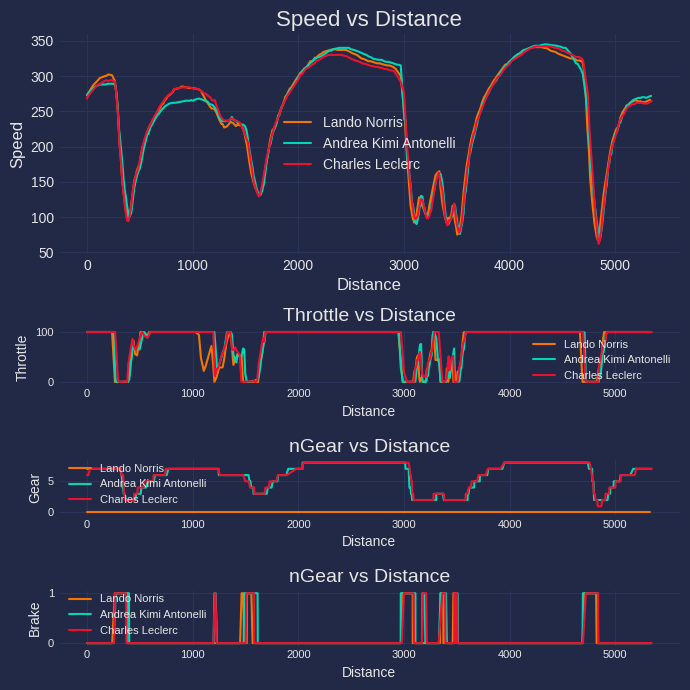

In [14]:
def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip("#")
    r, g, b = [int(hex_color[i : i + 2], 16) for i in (0, 2, 4)]
    return (r / 255, g / 255, b / 255)


def get_driver_color(driver_abbreviation):
    driver = SpQuali.get_driver(driver_abbreviation)
    team_color = driver.TeamColor
    return hex_to_rgb(team_color)


plt.style.use("cyberpunk")

fig, ax = plt.subplots(4, 1, figsize=(7, 7), gridspec_kw={"height_ratios": [4, 1, 1, 1]})

ax[0].plot(
    tele_nor_SpQuali.Distance, tele_nor_SpQuali.Speed, label="Lando Norris", color=get_driver_color("NOR")
)
ax[0].plot(
    tele_ant_SpQuali.Distance, tele_ant_SpQuali.Speed, label="Andrea Kimi Antonelli", color=get_driver_color("ANT")
)
ax[0].plot(
    tele_lec_SpQuali.Distance, tele_lec_SpQuali.Speed, label="Charles Leclerc", color=get_driver_color("LEC")
)

ax[0].set_title("Speed vs Distance", fontsize=16)
ax[0].set_xlabel("Distance", fontsize=12)
ax[0].set_ylabel("Speed", fontsize=12)
ax[0].legend(fontsize=10)
ax[0].grid(True)
ax[0].tick_params(axis="both", which="major", labelsize=10)
ax[1].plot(
    tele_nor_SpQuali.Distance, tele_nor_SpQuali.Throttle, label="Lando Norris", color=get_driver_color("NOR")
)
ax[1].plot(
    tele_ant_SpQuali.Distance, tele_ant_SpQuali.Throttle, label="Andrea Kimi Antonelli", color=get_driver_color("ANT")
)
ax[1].plot(
    tele_lec_SpQuali.Distance, tele_lec_SpQuali.Throttle, label="Charles Leclerc", color=get_driver_color("LEC")
)

ax[1].set_title("Throttle vs Distance", fontsize=14)
ax[1].set_xlabel("Distance", fontsize=10)
ax[1].set_ylabel("Throttle", fontsize=10)
ax[1].legend(fontsize=8)
ax[1].grid(True)
ax[1].tick_params(axis="both", which="major", labelsize=8)
ax[2].plot(
    tele_nor_SpQuali.Distance, tele_nor_SpQuali.nGear, label="Lando Norris", color=get_driver_color("NOR")
)
ax[2].plot(
    tele_ant_SpQuali.Distance, tele_ant_SpQuali.nGear, label="Andrea Kimi Antonelli", color=get_driver_color("ANT")
)
ax[2].plot(
    tele_lec_SpQuali.Distance, tele_lec_SpQuali.nGear, label="Charles Leclerc", color=get_driver_color("LEC")
)

ax[2].set_title("nGear vs Distance", fontsize=14)
ax[2].set_xlabel("Distance", fontsize=10)
ax[2].set_ylabel("Gear", fontsize=10)
ax[2].legend(fontsize=8)
ax[2].grid(True)
ax[2].tick_params(axis="both", which="major", labelsize=8)
ax[3].plot(
    tele_nor_SpQuali.Distance, tele_nor_SpQuali.Brake, label="Lando Norris", color=get_driver_color("NOR")
)
ax[3].plot(
    tele_ant_SpQuali.Distance, tele_ant_SpQuali.Brake, label="Andrea Kimi Antonelli", color=get_driver_color("ANT")
)
ax[3].plot(
    tele_lec_SpQuali.Distance, tele_lec_SpQuali.Brake, label="Charles Leclerc", color=get_driver_color("LEC")
)

ax[3].set_title("nGear vs Distance", fontsize=14)
ax[3].set_xlabel("Distance", fontsize=10)
ax[3].set_ylabel("Brake", fontsize=10)
ax[3].legend(fontsize=8)
ax[3].grid(True)
ax[3].tick_params(axis="both", which="major", labelsize=8)

plt.tight_layout()
plt.show()


In [15]:
driver1_sectors = pd.DataFrame(
    {
         "Driver": ["Lando Norris"] * len(nor_SpQuali_sec1),
        "Sector1Time": nor_SpQuali_sec1,
        "Sector2Time": nor_SpQuali_sec2,
        "Sector3Time": nor_SpQuali_sec3,
        "Lap Time": nor_SpQuali_lap_time,
    }
)


driver2_sectors = pd.DataFrame(
    {
         "Driver": ["Andrea Kimi Antonelli"] * len(ant_SpQuali_sec1),
        "Sector1Time": ant_SpQuali_sec1,
        "Sector2Time": ant_SpQuali_sec2,
        "Sector3Time": ant_SpQuali_sec3,
        "Lap Time": ant_SpQuali_lap_time,
    }
)


driver3_sectors = pd.DataFrame(
    {
         "Driver": ["Charles Leclerc"] * len(lec_SpQuali_sec1),
        "Sector1Time": lec_SpQuali_sec1,
        "Sector2Time": lec_SpQuali_sec2,
        "Sector3Time": lec_SpQuali_sec3,
        "Lap Time": lec_SpQuali_lap_time,
    }
)


all_drivers_sectors = pd.concat(
    [driver1_sectors, driver2_sectors, driver3_sectors],
    ignore_index=True,
)
all_drivers_sectors.sort_values(
    by=["Sector1Time", "Sector2Time", "Sector3Time"], ascending=True
)
all_drivers_sectors.dropna()

,Driver,Sector1Time,Sector2Time,Sector3Time,Lap Time
1,Lando Norris,0 days 00:00:30.647000,0 days 00:00:33.764000,0 days 00:00:35.295000,0 days 00:01:39.706000
2,Lando Norris,0 days 00:00:45.383000,0 days 00:00:43.551000,0 days 00:00:32.224000,0 days 00:02:01.158000
3,Lando Norris,0 days 00:00:30.179000,0 days 00:00:33.615000,0 days 00:00:24.929000,0 days 00:01:28.723000
4,Lando Norris,0 days 00:00:43.060000,0 days 00:00:47.713000,0 days 00:00:42.066000,0 days 00:02:12.839000
5,Lando Norris,0 days 00:00:30.315000,0 days 00:00:33.709000,0 days 00:00:24.782000,0 days 00:01:28.806000
6,Lando Norris,0 days 00:00:39.009000,0 days 00:00:44.482000,0 days 00:00:40.106000,0 days 00:02:03.597000
8,Lando Norris,0 days 00:00:29.960000,0 days 00:00:34.152000,0 days 00:00:25.254000,0 days 00:01:29.366000
9,Lando Norris,0 days 00:00:42.500000,0 days 00:00:44.603000,0 days 00:00:34.559000,0 days 00:02:01.662000
10,Lando Norris,0 days 00:00:43.838000,0 days 00:00:46.194000,0 days 00:00:41.185000,0 days 00:02:11.217000
11,Lando Norris,0 days 00:00:30.565000,0 days 00:00:33.688000,0 days 00:00:41.727000,0 days 00:01:45.980000


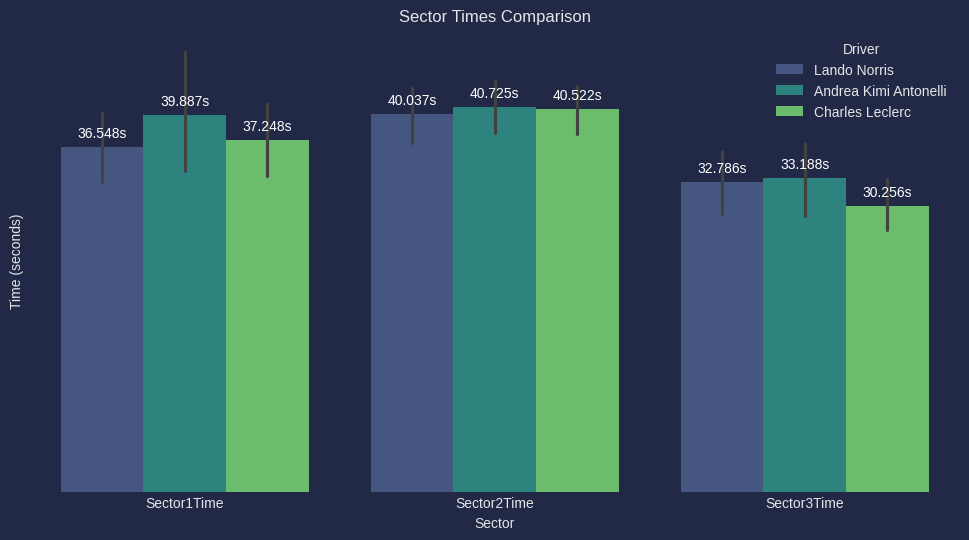

In [16]:
melted_data = all_drivers_sectors.melt(
    id_vars=["Driver"],
    value_vars=["Sector1Time", "Sector2Time", "Sector3Time"],
    var_name="Sector",
    value_name="Time",
)

melted_data["Time"] = melted_data["Time"].dt.total_seconds()

plt.figure(figsize=(12, 6))

bar_plot = sns.barplot(
    data=melted_data, x="Sector", y="Time", hue="Driver", palette="viridis"
)

for p in bar_plot.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        bar_plot.annotate(
            f"{height:.3f}s",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
        va="bottom",
            fontsize=10,
            color="white",
            xytext=(0, 5),
            textcoords="offset points",
        )

plt.title("Sector Times Comparison")
plt.ylabel("Time (seconds)")
plt.xlabel("Sector")
plt.gca().set_yticks([])
plt.show()

*Sprint Race*

In [17]:
sprint = f1.get_session(2026, "Miami", "Sprint")
sprint.load()

core           INFO 	Loading data for Miami Grand Prix - Sprint [v3.8.1]


req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data


req            INFO 	Using cached data for lap_count


...

req            INFO 	Using cached data for car_data


req            INFO 	Using cached data for position_data


req            INFO 	Using cached data for weather_data


req            INFO 	Using cached data for race_control_messages


core           INFO 	Finished loading data for 22 drivers: ['1', '81', '16', '63', '3', '12', '44', '10', '6', '43', '31', '87', '55', '30', '14', '11', '18', '23', '77', '27', '41', '5']


In [18]:
sprint.session_info

{'Meeting': {'Key': 1284,
  'Name': 'Miami Grand Prix',
  'OfficialName': 'FORMULA 1 CRYPTO.COM MIAMI GRAND PRIX 2026',
  'Location': 'Miami Gardens',
  'Number': 6,
  'Country': {'Key': 19, 'Code': 'USA', 'Name': 'United States'},
  'Circuit': {'Key': 151, 'ShortName': 'Miami'}},
 'SessionStatus': 'Inactive',
 'ArchiveStatus': {'Status': 'Generating'},
 'Key': 11275,
 'Type': 'Race',
 'Name': 'Sprint',
 'StartDate': datetime.datetime(2026, 5, 2, 12, 0),
 'EndDate': datetime.datetime(2026, 5, 2, 13, 0),
 'GmtOffset': datetime.timedelta(days=-1, seconds=72000),
 'Path': '2026/2026-05-03_Miami_Grand_Prix/2026-05-02_Sprint/'}

In [19]:
sprint.results.loc[
    :, ["Abbreviation", "TeamName", "GridPosition", "Position", "Time", "Status"]
]

,Abbreviation,TeamName,GridPosition,Position,Time,Status
1,NOR,McLaren,1.0,1.0,0 days 00:29:15.045000,Finished
81,PIA,McLaren,3.0,2.0,0 days 00:00:03.766000,Finished
16,LEC,Ferrari,4.0,3.0,0 days 00:00:06.251000,Finished
63,RUS,Mercedes,6.0,4.0,0 days 00:00:12.951000,Finished
3,VER,Red Bull Racing,5.0,5.0,0 days 00:00:13.639000,Finished
12,ANT,Mercedes,2.0,6.0,0 days 00:00:13.777000,Finished
44,HAM,Ferrari,7.0,7.0,0 days 00:00:21.665000,Finished
10,GAS,Alpine,10.0,8.0,0 days 00:00:30.525000,Finished
6,HAD,Red Bull Racing,9.0,9.0,0 days 00:00:35.346000,Finished
43,COL,Alpine,8.0,10.0,0 days 00:00:36.970000,Finished


In [20]:
sprint_laps = sprint.laps
sprint_laps

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:45:45.655000,NOR,1,NaT,1.0,1.0,NaT,NaT,NaT,0 days 00:00:34.285000,...,True,McLaren,0 days 00:44:11.427000,2026-05-02 16:03:50.572,1,1.0,False,,False,False
1,0 days 00:47:18.229000,NOR,1,0 days 00:01:32.574000,2.0,1.0,NaT,NaT,0 days 00:00:31.618000,0 days 00:00:34.972000,...,True,McLaren,0 days 00:45:45.655000,2026-05-02 16:05:24.800,1,1.0,False,,False,True
2,0 days 00:48:50.412000,NOR,1,0 days 00:01:32.183000,3.0,1.0,NaT,NaT,0 days 00:00:31.634000,0 days 00:00:34.770000,...,True,McLaren,0 days 00:47:18.229000,2026-05-02 16:06:57.374,1,1.0,False,,False,True
3,0 days 00:50:23.012000,NOR,1,0 days 00:01:32.600000,4.0,1.0,NaT,NaT,0 days 00:00:31.657000,0 days 00:00:35.077000,...,True,McLaren,0 days 00:48:50.412000,2026-05-02 16:08:29.557,1,1.0,False,,False,True
4,0 days 00:51:55.597000,NOR,1,0 days 00:01:32.585000,5.0,1.0,NaT,NaT,0 days 00:00:31.861000,0 days 00:00:34.863000,...,True,McLaren,0 days 00:50:23.012000,2026-05-02 16:10:02.157,1,1.0,False,,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377,0 days 01:07:56.981000,BOR,5,0 days 00:01:34.714000,15.0,1.0,NaT,NaT,0 days 00:00:32.620000,0 days 00:00:35.789000,...,False,Audi,0 days 01:06:22.267000,2026-05-02 16:26:01.412,1,11.0,False,,False,True
378,0 days 01:09:31.616000,BOR,5,0 days 00:01:34.635000,16.0,1.0,NaT,NaT,0 days 00:00:32.713000,0 days 00:00:35.501000,...,False,Audi,0 days 01:07:56.981000,2026-05-02 16:27:36.126,1,11.0,False,,False,True
379,0 days 01:11:06.015000,BOR,5,0 days 00:01:34.399000,17.0,1.0,NaT,NaT,0 days 00:00:32.498000,0 days 00:00:35.596000,...,False,Audi,0 days 01:09:31.616000,2026-05-02 16:29:10.761,1,11.0,False,,False,True
380,0 days 01:12:40.760000,BOR,5,0 days 00:01:34.745000,18.0,1.0,NaT,NaT,0 days 00:00:32.726000,0 days 00:00:35.726000,...,False,Audi,0 days 01:11:06.015000,2026-05-02 16:30:45.160,1,11.0,False,,False,True


In [21]:
nor_sprint_laps = sprint.laps.pick_driver("NOR")
fastest_lap_nor_sprint = nor_sprint_laps.pick_fastest().LapTime
nor_sprint_lap_time = nor_sprint_laps["LapTime"]
nor_sprint_sec1 = nor_sprint_laps["Sector1Time"]
nor_sprint_sec2 = nor_sprint_laps["Sector2Time"]
nor_sprint_sec3 = nor_sprint_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(fastest_lap_nor_sprint), "which was in Lap number" ,nor_sprint_laps.pick_fastest().LapNumber)
nor_sprint_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:31.885000 which was in Lap number 10.0


/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
0,NaT,NaT,0 days 00:00:34.285000,0 days 00:00:25.979000,214.0,188.0,276.0,295.0
1,0 days 00:01:32.574000,0 days 00:00:31.618000,0 days 00:00:34.972000,0 days 00:00:25.984000,216.0,185.0,270.0,299.0
2,0 days 00:01:32.183000,0 days 00:00:31.634000,0 days 00:00:34.770000,0 days 00:00:25.779000,216.0,188.0,273.0,300.0
3,0 days 00:01:32.600000,0 days 00:00:31.657000,0 days 00:00:35.077000,0 days 00:00:25.866000,217.0,183.0,274.0,299.0
4,0 days 00:01:32.585000,0 days 00:00:31.861000,0 days 00:00:34.863000,0 days 00:00:25.861000,216.0,186.0,276.0,299.0


In [22]:
fastest_lap_nor_sprint = nor_sprint_laps.pick_fastest()
tele_nor_sprint = fastest_lap_nor_sprint.get_telemetry().add_distance()
speed_nor_sprint = tele_nor_sprint.Speed
tele_nor_sprint.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,285.600000,8,10451.000000
3,286.181818,8,10462.636364
4,287.000000,8,10479.000000
5,287.714286,8,10503.285714
6,288.000000,8,10513.000000
...,...,...,...
676,283.000000,8,10379.000000
677,283.095000,8,10379.332501
678,284.995000,8,10385.982501
679,285.000000,8,10386.000000


In [23]:
lec_sprint_laps = sprint.laps.pick_driver("LEC")
fastest_lap_lec_sprint = lec_sprint_laps.pick_fastest().LapTime
lec_sprint_lap_time = lec_sprint_laps["LapTime"]
lec_sprint_sec1 = lec_sprint_laps["Sector1Time"]
lec_sprint_sec2 = lec_sprint_laps["Sector2Time"]
lec_sprint_sec3 = lec_sprint_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(fastest_lap_lec_sprint), "which was in Lap number" ,lec_sprint_laps.pick_fastest().LapNumber)
lec_sprint_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:31.964000 which was in Lap number 11.0


/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
38,NaT,NaT,0 days 00:00:34.899000,0 days 00:00:25.671000,217.0,188.0,287.0,290.0
39,0 days 00:01:32.767000,0 days 00:00:32.236000,0 days 00:00:34.865000,0 days 00:00:25.666000,213.0,186.0,292.0,292.0
40,0 days 00:01:32.704000,0 days 00:00:32.084000,0 days 00:00:34.744000,0 days 00:00:25.876000,212.0,184.0,291.0,305.0
41,0 days 00:01:33.067000,0 days 00:00:32.065000,0 days 00:00:35.206000,0 days 00:00:25.796000,213.0,184.0,281.0,302.0
42,0 days 00:01:32.488000,0 days 00:00:31.776000,0 days 00:00:35.006000,0 days 00:00:25.706000,212.0,185.0,284.0,304.0


In [24]:
fastest_lap_lec_sprint = lec_sprint_laps.pick_fastest()
tele_lec_sprint = fastest_lap_lec_sprint.get_telemetry().add_distance()
speed_lec_sprint = tele_lec_sprint.Speed
tele_lec_sprint.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,292.787500,7,11557.125000
3,293.490626,7,11568.843760
4,294.990626,7,11593.843760
5,295.000000,7,11594.000000
6,295.000000,7,11619.550007
...,...,...,...
686,282.694236,7,11175.877214
687,283.000000,7,11193.000000
688,285.560715,7,11244.214299
689,286.000000,7,11253.000000


In [25]:
ver_sprint_laps = sprint.laps.pick_driver("VER")
fastest_lap_ver_sprint = ver_sprint_laps.pick_fastest().LapTime
ver_sprint_lap_time = ver_sprint_laps["LapTime"]
ver_sprint_sec1 = ver_sprint_laps["Sector1Time"]
ver_sprint_sec2 = ver_sprint_laps["Sector2Time"]
ver_sprint_sec3 = ver_sprint_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(fastest_lap_ver_sprint), "which was in Lap number" ,ver_sprint_laps.pick_fastest().LapNumber)
ver_sprint_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:32.201000 which was in Lap number 19.0


/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
76,NaT,NaT,0 days 00:00:34.813000,0 days 00:00:26.222000,216.0,188.0,246.0,314.0
77,0 days 00:01:33.225000,0 days 00:00:32.677000,0 days 00:00:34.843000,0 days 00:00:25.705000,210.0,176.0,275.0,316.0
78,0 days 00:01:32.914000,0 days 00:00:32.354000,0 days 00:00:34.899000,0 days 00:00:25.661000,216.0,183.0,250.0,328.0
79,0 days 00:01:33.160000,0 days 00:00:32.522000,0 days 00:00:34.906000,0 days 00:00:25.732000,217.0,185.0,252.0,321.0
80,0 days 00:01:32.673000,0 days 00:00:32.461000,0 days 00:00:34.762000,0 days 00:00:25.450000,219.0,185.0,282.0,317.0


In [26]:
fastest_lap_ver_sprint = ver_sprint_laps.pick_fastest()
tele_ver_sprint = fastest_lap_ver_sprint.get_telemetry().add_distance()
speed_ver_sprint = tele_ver_sprint.Speed
tele_ver_sprint.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,266.550000,7,10705.700000
3,267.000000,7,10748.000000
4,267.582089,7,10778.268650
5,267.980099,7,10798.965174
6,268.000000,7,10800.000000
...,...,...,...
687,268.000000,7,10810.000000
688,269.205555,7,10719.583360
689,270.000000,7,10660.000000
690,269.684211,7,10629.684239


In [27]:
rus_sprint_laps = sprint.laps.pick_driver("RUS")
fastest_lap_rus_sprint = rus_sprint_laps.pick_fastest().LapTime
rus_sprint_lap_time = rus_sprint_laps["LapTime"]
rus_sprint_sec1 = rus_sprint_laps["Sector1Time"]
rus_sprint_sec2 = rus_sprint_laps["Sector2Time"]
rus_sprint_sec3 = rus_sprint_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(fastest_lap_rus_sprint), "which was in Lap number" ,rus_sprint_laps.pick_fastest().LapNumber)
rus_sprint_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:32.387000 which was in Lap number 10.0


/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
57,NaT,NaT,0 days 00:00:35.166000,0 days 00:00:25.753000,218.0,183.0,285.0,299.0
58,0 days 00:01:33.046000,0 days 00:00:32.201000,0 days 00:00:35.132000,0 days 00:00:25.713000,216.0,189.0,281.0,316.0
59,0 days 00:01:32.658000,0 days 00:00:32.272000,0 days 00:00:34.825000,0 days 00:00:25.561000,214.0,187.0,277.0,323.0
60,0 days 00:01:32.829000,0 days 00:00:32.268000,0 days 00:00:35.008000,0 days 00:00:25.553000,214.0,185.0,283.0,322.0
61,0 days 00:01:32.748000,0 days 00:00:32.329000,0 days 00:00:34.976000,0 days 00:00:25.443000,214.0,184.0,294.0,321.0


In [28]:
fastest_lap_rus_sprint = rus_sprint_laps.pick_fastest()
tele_rus_sprint = fastest_lap_rus_sprint.get_telemetry().add_distance()
speed_rus_sprint = tele_rus_sprint.Speed
tele_rus_sprint.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,288.224999,7,11126.674959
3,288.450000,7,11136.350000
4,290.700000,7,11233.100000
5,291.000000,7,11246.000000
6,291.997733,7,11277.428576
...,...,...,...
678,285.883334,7,11008.004179
679,286.000000,7,11012.000000
680,287.000000,7,11201.000000
681,287.666667,7,11212.500000


In [29]:
driver1_sectors = pd.DataFrame(
    {
         "Driver": ["Lando Norris"] * len(nor_sprint_sec1),
        "Sector1Time": nor_sprint_sec1,
        "Sector2Time": nor_sprint_sec2,
        "Sector3Time": nor_sprint_sec3,
        "Lap Time": nor_sprint_lap_time,
    }
)


driver2_sectors = pd.DataFrame(
    {
         "Driver": ["Charles Leclerc"] * len(lec_sprint_sec1),
        "Sector1Time": lec_sprint_sec1,
        "Sector2Time": lec_sprint_sec2,
        "Sector3Time": lec_sprint_sec3,
        "Lap Time": lec_sprint_lap_time,
    }
)


driver3_sectors = pd.DataFrame(
    {
         "Driver": ["Max Verstappen"] * len(ver_sprint_sec1),
        "Sector1Time": ver_sprint_sec1,
        "Sector2Time": ver_sprint_sec2,
        "Sector3Time": ver_sprint_sec3,
        "Lap Time": ver_sprint_lap_time,
    }
)


driver4_sectors = pd.DataFrame(
    {
         "Driver": ["George Russell"] * len(rus_sprint_sec1),
        "Sector1Time": rus_sprint_sec1,
        "Sector2Time": rus_sprint_sec2,
        "Sector3Time": rus_sprint_sec3,
        "Lap Time": rus_sprint_lap_time,
    }
)


all_drivers_sectors = pd.concat(
    [driver1_sectors, driver2_sectors, driver3_sectors, driver4_sectors],
    ignore_index=True,
)
all_drivers_sectors.sort_values(
    by=["Sector1Time", "Sector2Time", "Sector3Time"], ascending=True
)
all_drivers_sectors.dropna()

,Driver,Sector1Time,Sector2Time,Sector3Time,Lap Time
1,Lando Norris,0 days 00:00:31.618000,0 days 00:00:34.972000,0 days 00:00:25.984000,0 days 00:01:32.574000
2,Lando Norris,0 days 00:00:31.634000,0 days 00:00:34.770000,0 days 00:00:25.779000,0 days 00:01:32.183000
3,Lando Norris,0 days 00:00:31.657000,0 days 00:00:35.077000,0 days 00:00:25.866000,0 days 00:01:32.600000
4,Lando Norris,0 days 00:00:31.861000,0 days 00:00:34.863000,0 days 00:00:25.861000,0 days 00:01:32.585000
5,Lando Norris,0 days 00:00:31.692000,0 days 00:00:34.668000,0 days 00:00:25.569000,0 days 00:01:31.929000
...,...,...,...,...,...
71,George Russell,0 days 00:00:31.860000,0 days 00:00:35.249000,0 days 00:00:25.738000,0 days 00:01:32.847000
72,George Russell,0 days 00:00:31.915000,0 days 00:00:35.094000,0 days 00:00:25.718000,0 days 00:01:32.727000
73,George Russell,0 days 00:00:31.996000,0 days 00:00:36.081000,0 days 00:00:25.654000,0 days 00:01:33.731000
74,George Russell,0 days 00:00:31.685000,0 days 00:00:35.283000,0 days 00:00:25.524000,0 days 00:01:32.492000


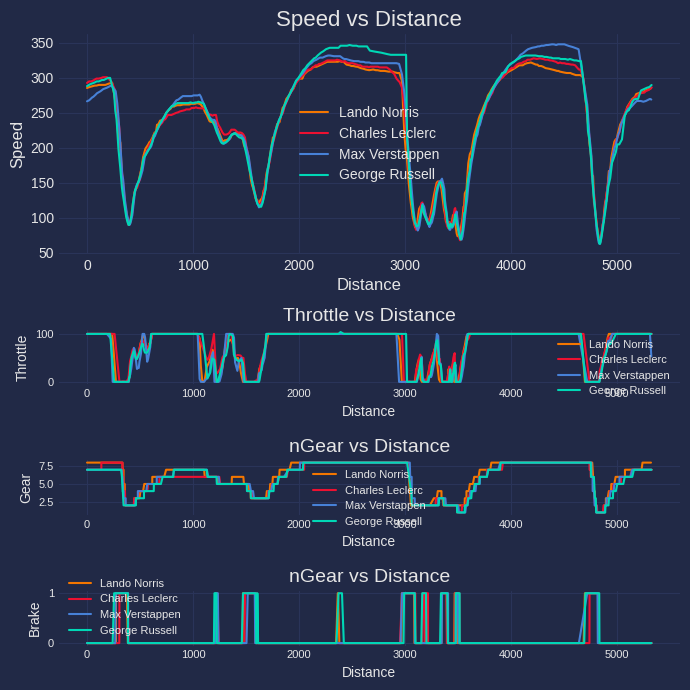

In [30]:
def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip("#")
    r, g, b = [int(hex_color[i : i + 2], 16) for i in (0, 2, 4)]
    return (r / 255, g / 255, b / 255)


def get_driver_color(driver_abbreviation):
    driver = sprint.get_driver(driver_abbreviation)
    team_color = driver.TeamColor
    return hex_to_rgb(team_color)


plt.style.use("cyberpunk")

fig, ax = plt.subplots(4, 1, figsize=(7, 7), gridspec_kw={"height_ratios": [4, 1, 1, 1]})

ax[0].plot(
    tele_nor_sprint.Distance, tele_nor_sprint.Speed, label="Lando Norris", color=get_driver_color("NOR")
)
ax[0].plot(
    tele_lec_sprint.Distance, tele_lec_sprint.Speed, label="Charles Leclerc", color=get_driver_color("LEC")
)
ax[0].plot(
    tele_ver_sprint.Distance, tele_ver_sprint.Speed, label="Max Verstappen", color=get_driver_color("VER")
)
ax[0].plot(
    tele_rus_sprint.Distance, tele_rus_sprint.Speed, label="George Russell", color=get_driver_color("RUS")
)

ax[0].set_title("Speed vs Distance", fontsize=16)
ax[0].set_xlabel("Distance", fontsize=12)
ax[0].set_ylabel("Speed", fontsize=12)
ax[0].legend(fontsize=10)
ax[0].grid(True)
ax[0].tick_params(axis="both", which="major", labelsize=10)
ax[1].plot(
    tele_nor_sprint.Distance, tele_nor_sprint.Throttle, label="Lando Norris", color=get_driver_color("NOR")
)
ax[1].plot(
    tele_lec_sprint.Distance, tele_lec_sprint.Throttle, label="Charles Leclerc", color=get_driver_color("LEC")
)
ax[1].plot(
    tele_ver_sprint.Distance, tele_ver_sprint.Throttle, label="Max Verstappen", color=get_driver_color("VER")
)
ax[1].plot(
    tele_rus_sprint.Distance, tele_rus_sprint.Throttle, label="George Russell", color=get_driver_color("RUS")
)

ax[1].set_title("Throttle vs Distance", fontsize=14)
ax[1].set_xlabel("Distance", fontsize=10)
ax[1].set_ylabel("Throttle", fontsize=10)
ax[1].legend(fontsize=8)
ax[1].grid(True)
ax[1].tick_params(axis="both", which="major", labelsize=8)
ax[2].plot(
    tele_nor_sprint.Distance, tele_nor_sprint.nGear, label="Lando Norris", color=get_driver_color("NOR")
)
ax[2].plot(
    tele_lec_sprint.Distance, tele_lec_sprint.nGear, label="Charles Leclerc", color=get_driver_color("LEC")
)
ax[2].plot(
    tele_ver_sprint.Distance, tele_ver_sprint.nGear, label="Max Verstappen", color=get_driver_color("VER")
)
ax[2].plot(
    tele_rus_sprint.Distance, tele_rus_sprint.nGear, label="George Russell", color=get_driver_color("RUS")
)

ax[2].set_title("nGear vs Distance", fontsize=14)
ax[2].set_xlabel("Distance", fontsize=10)
ax[2].set_ylabel("Gear", fontsize=10)
ax[2].legend(fontsize=8)
ax[2].grid(True)
ax[2].tick_params(axis="both", which="major", labelsize=8)
ax[3].plot(
    tele_nor_sprint.Distance, tele_nor_sprint.Brake, label="Lando Norris", color=get_driver_color("NOR")
)
ax[3].plot(
    tele_lec_sprint.Distance, tele_lec_sprint.Brake, label="Charles Leclerc", color=get_driver_color("LEC")
)
ax[3].plot(
    tele_ver_sprint.Distance, tele_ver_sprint.Brake, label="Max Verstappen", color=get_driver_color("VER")
)
ax[3].plot(
    tele_rus_sprint.Distance, tele_rus_sprint.Brake, label="George Russell", color=get_driver_color("RUS")
)

ax[3].set_title("nGear vs Distance", fontsize=14)
ax[3].set_xlabel("Distance", fontsize=10)
ax[3].set_ylabel("Brake", fontsize=10)
ax[3].legend(fontsize=8)
ax[3].grid(True)
ax[3].tick_params(axis="both", which="major", labelsize=8)

plt.tight_layout()
plt.show()


In [31]:
driver1_sectors = pd.DataFrame(
    {
         "Driver": ["Lando Norris"] * len(nor_sprint_sec1),
        "Sector1Time": nor_sprint_sec1,
        "Sector2Time": nor_sprint_sec2,
        "Sector3Time": nor_sprint_sec3,
        "Lap Time": nor_sprint_lap_time,
    }
)


driver2_sectors = pd.DataFrame(
    {
         "Driver": ["Charles Leclerc"] * len(lec_sprint_sec1),
        "Sector1Time": lec_sprint_sec1,
        "Sector2Time": lec_sprint_sec2,
        "Sector3Time": lec_sprint_sec3,
        "Lap Time": lec_sprint_lap_time,
    }
)


driver3_sectors = pd.DataFrame(
    {
         "Driver": ["Max Verstappen"] * len(ver_sprint_sec1),
        "Sector1Time": ver_sprint_sec1,
        "Sector2Time": ver_sprint_sec2,
        "Sector3Time": ver_sprint_sec3,
        "Lap Time": ver_sprint_lap_time,
    }
)


driver4_sectors = pd.DataFrame(
    {
         "Driver": ["George Russell"] * len(rus_sprint_sec1),
        "Sector1Time": rus_sprint_sec1,
        "Sector2Time": rus_sprint_sec2,
        "Sector3Time": rus_sprint_sec3,
        "Lap Time": rus_sprint_lap_time,
    }
)


all_drivers_sectors = pd.concat(
    [driver1_sectors, driver2_sectors, driver3_sectors, driver4_sectors],
    ignore_index=True,
)
all_drivers_sectors.sort_values(
    by=["Sector1Time", "Sector2Time", "Sector3Time"], ascending=True
)
all_drivers_sectors.dropna()

,Driver,Sector1Time,Sector2Time,Sector3Time,Lap Time
1,Lando Norris,0 days 00:00:31.618000,0 days 00:00:34.972000,0 days 00:00:25.984000,0 days 00:01:32.574000
2,Lando Norris,0 days 00:00:31.634000,0 days 00:00:34.770000,0 days 00:00:25.779000,0 days 00:01:32.183000
3,Lando Norris,0 days 00:00:31.657000,0 days 00:00:35.077000,0 days 00:00:25.866000,0 days 00:01:32.600000
4,Lando Norris,0 days 00:00:31.861000,0 days 00:00:34.863000,0 days 00:00:25.861000,0 days 00:01:32.585000
5,Lando Norris,0 days 00:00:31.692000,0 days 00:00:34.668000,0 days 00:00:25.569000,0 days 00:01:31.929000
...,...,...,...,...,...
71,George Russell,0 days 00:00:31.860000,0 days 00:00:35.249000,0 days 00:00:25.738000,0 days 00:01:32.847000
72,George Russell,0 days 00:00:31.915000,0 days 00:00:35.094000,0 days 00:00:25.718000,0 days 00:01:32.727000
73,George Russell,0 days 00:00:31.996000,0 days 00:00:36.081000,0 days 00:00:25.654000,0 days 00:01:33.731000
74,George Russell,0 days 00:00:31.685000,0 days 00:00:35.283000,0 days 00:00:25.524000,0 days 00:01:32.492000


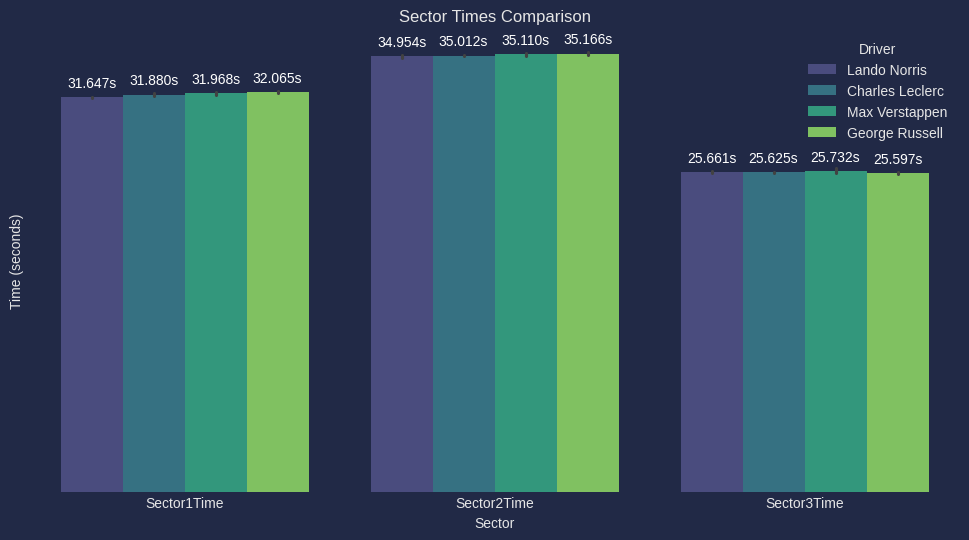

In [32]:
melted_data = all_drivers_sectors.melt(
    id_vars=["Driver"],
    value_vars=["Sector1Time", "Sector2Time", "Sector3Time"],
    var_name="Sector",
    value_name="Time",
)

melted_data["Time"] = melted_data["Time"].dt.total_seconds()

plt.figure(figsize=(12, 6))

bar_plot = sns.barplot(
    data=melted_data, x="Sector", y="Time", hue="Driver", palette="viridis"
)

for p in bar_plot.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        bar_plot.annotate(
            f"{height:.3f}s",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
        va="bottom",
            fontsize=10,
            color="white",
            xytext=(0, 5),
            textcoords="offset points",
        )

plt.title("Sector Times Comparison")
plt.ylabel("Time (seconds)")
plt.xlabel("Sector")
plt.gca().set_yticks([])
plt.show()

*Qualifying*

In [33]:
quali = f1.get_session(2026, "Miami", "Qualifying")
quali.load()

core           INFO 	Loading data for Miami Grand Prix - Qualifying [v3.8.1]


req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data


req            INFO 	Using cached data for track_status_data


...

req            INFO 	Using cached data for car_data


req            INFO 	Using cached data for position_data


req            INFO 	Using cached data for weather_data


req            INFO 	Using cached data for race_control_messages


core           INFO 	Finished loading data for 22 drivers: ['12', '3', '16', '1', '63', '44', '81', '43', '10', '27', '30', '87', '55', '31', '23', '41', '14', '18', '77', '11', '5', '6']


In [34]:
quali.session_info

{'Meeting': {'Key': 1284,
  'Name': 'Miami Grand Prix',
  'OfficialName': 'FORMULA 1 CRYPTO.COM MIAMI GRAND PRIX 2026',
  'Location': 'Miami Gardens',
  'Number': 6,
  'Country': {'Key': 19, 'Code': 'USA', 'Name': 'United States'},
  'Circuit': {'Key': 151, 'ShortName': 'Miami'}},
 'SessionStatus': 'Inactive',
 'ArchiveStatus': {'Status': 'Generating'},
 'Key': 11276,
 'Type': 'Qualifying',
 'Name': 'Qualifying',
 'StartDate': datetime.datetime(2026, 5, 2, 16, 0),
 'EndDate': datetime.datetime(2026, 5, 2, 17, 0),
 'GmtOffset': datetime.timedelta(days=-1, seconds=72000),
 'Path': '2026/2026-05-03_Miami_Grand_Prix/2026-05-02_Qualifying/'}

In [35]:
quali.results.loc[
    :, ["Abbreviation", "TeamName", "GridPosition", "Position", "Time", "Status"]
]

,Abbreviation,TeamName,GridPosition,Position,Time,Status
12,ANT,Mercedes,NaN,1.0,NaT,
3,VER,Red Bull Racing,NaN,2.0,NaT,
16,LEC,Ferrari,NaN,3.0,NaT,
1,NOR,McLaren,NaN,4.0,NaT,
63,RUS,Mercedes,NaN,5.0,NaT,
44,HAM,Ferrari,NaN,6.0,NaT,
81,PIA,McLaren,NaN,7.0,NaT,
43,COL,Alpine,NaN,8.0,NaT,
10,GAS,Alpine,NaN,9.0,NaT,
27,HUL,Audi,NaN,10.0,NaT,


In [36]:
quali_laps = quali.laps
quali_laps

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:18:53.464000,ANT,12,NaT,1.0,1.0,0 days 00:17:01.643000,NaT,NaT,0 days 00:00:43.904000,...,False,Mercedes,0 days 00:17:01.643000,2026-05-02 20:04:19.440,1,NaN,False,,False,False
1,0 days 00:20:22.622000,ANT,12,0 days 00:01:29.158000,2.0,1.0,NaT,NaT,0 days 00:00:30.138000,0 days 00:00:33.991000,...,False,Mercedes,0 days 00:18:53.464000,2026-05-02 20:06:11.261,1,NaN,False,,False,True
2,0 days 00:22:27.294000,ANT,12,0 days 00:02:04.672000,3.0,1.0,NaT,0 days 00:22:21.426000,0 days 00:00:36.511000,0 days 00:00:47.737000,...,False,Mercedes,0 days 00:20:22.622000,2026-05-02 20:07:40.419,1,NaN,False,,False,False
3,0 days 00:27:05.605000,ANT,12,NaT,4.0,2.0,0 days 00:25:13.627000,NaT,NaT,0 days 00:00:42.641000,...,True,Mercedes,0 days 00:22:27.294000,2026-05-02 20:09:45.091,1,NaN,False,,False,False
4,0 days 00:28:34.258000,ANT,12,0 days 00:01:28.653000,5.0,2.0,NaT,NaT,0 days 00:00:29.817000,0 days 00:00:34.062000,...,True,Mercedes,0 days 00:27:05.605000,2026-05-02 20:14:23.402,1,NaN,False,,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,0 days 01:08:51.076000,HAD,6,0 days 00:01:28.789000,17.0,5.0,NaT,NaT,0 days 00:00:30.364000,0 days 00:00:33.545000,...,True,Red Bull Racing,0 days 01:07:22.287000,2026-05-02 20:54:40.084,1,NaN,False,,False,True
320,0 days 01:10:43.445000,HAD,6,0 days 00:01:52.369000,18.0,5.0,NaT,0 days 01:10:37.779000,0 days 00:00:34.546000,0 days 00:00:40.665000,...,True,Red Bull Racing,0 days 01:08:51.076000,2026-05-02 20:56:08.873,1,NaN,False,,False,False
321,0 days 01:16:26.272000,HAD,6,NaT,19.0,6.0,0 days 01:14:22.647000,NaT,NaT,0 days 00:00:46.796000,...,True,Red Bull Racing,0 days 01:10:43.445000,2026-05-02 20:58:01.242,1,NaN,False,,False,False
322,0 days 01:17:55.574000,HAD,6,0 days 00:01:29.302000,20.0,6.0,NaT,NaT,0 days 00:00:31.055000,0 days 00:00:33.398000,...,True,Red Bull Racing,0 days 01:16:26.272000,2026-05-02 21:03:44.069,1,NaN,False,,False,True


In [37]:
ant_quali_laps = quali.laps.pick_driver("ANT")
fastest_lap_ant_quali = ant_quali_laps.pick_fastest().LapTime
ant_quali_lap_time = ant_quali_laps["LapTime"]
ant_quali_sec1 = ant_quali_laps["Sector1Time"]
ant_quali_sec2 = ant_quali_laps["Sector2Time"]
ant_quali_sec3 = ant_quali_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(fastest_lap_ant_quali), "which was in Lap number" ,ant_quali_laps.pick_fastest().LapNumber)
ant_quali_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:27.798000 which was in Lap number 14.0


/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
0,NaT,NaT,0 days 00:00:43.904000,0 days 00:00:31.471000,171.0,116.0,269.0,249.0
1,0 days 00:01:29.158000,0 days 00:00:30.138000,0 days 00:00:33.991000,0 days 00:00:25.029000,218.0,193.0,270.0,324.0
2,0 days 00:02:04.672000,0 days 00:00:36.511000,0 days 00:00:47.737000,0 days 00:00:40.424000,158.0,140.0,NaN,104.0
3,NaT,NaT,0 days 00:00:42.641000,0 days 00:00:33.604000,177.0,69.0,271.0,247.0
4,0 days 00:01:28.653000,0 days 00:00:29.817000,0 days 00:00:34.062000,0 days 00:00:24.774000,219.0,192.0,268.0,324.0


In [38]:
fastest_lap_ant_quali = ant_quali_laps.pick_fastest()
tele_ant_quali = fastest_lap_ant_quali.get_telemetry().add_distance()
speed_ant_quali = tele_ant_quali.Speed
tele_ant_quali.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,280.450000,7,10835.125000
3,281.487498,7,10899.968600
4,282.000000,7,10932.000000
5,287.000000,7,11095.000000
6,287.000000,7,11130.887523
...,...,...,...
638,268.000000,7,10374.000000
639,268.618750,7,10404.318770
640,269.993749,7,10471.693691
641,270.000000,7,10472.000000


In [39]:
ver_quali_laps = quali.laps.pick_driver("VER")
fastest_lap_ver_quali = ver_quali_laps.pick_fastest().LapTime
ver_quali_lap_time = ver_quali_laps["LapTime"]
ver_quali_sec1 = ver_quali_laps["Sector1Time"]
ver_quali_sec2 = ver_quali_laps["Sector2Time"]
ver_quali_sec3 = ver_quali_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(fastest_lap_ver_quali), "which was in Lap number" ,ver_quali_laps.pick_fastest().LapNumber)
ver_quali_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:27.964000 which was in Lap number 14.0


/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
17,NaT,NaT,0 days 00:00:38.549000,0 days 00:00:35.910000,200.0,167.0,262.0,182.0
18,0 days 00:01:29.099000,0 days 00:00:30.369000,0 days 00:00:33.772000,0 days 00:00:24.958000,222.0,192.0,269.0,319.0
19,0 days 00:01:48.451000,0 days 00:00:34.388000,0 days 00:00:38.203000,0 days 00:00:35.860000,205.0,166.0,NaN,213.0
20,NaT,NaT,0 days 00:00:40.073000,0 days 00:00:30.431000,207.0,111.0,266.0,248.0
21,0 days 00:01:28.931000,0 days 00:00:30.398000,0 days 00:00:33.765000,0 days 00:00:24.768000,224.0,193.0,274.0,322.0


In [40]:
fastest_lap_ver_quali = ver_quali_laps.pick_fastest()
tele_ver_quali = fastest_lap_ver_quali.get_telemetry().add_distance()
speed_ver_quali = tele_ver_quali.Speed
tele_ver_quali.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,277.521735,7,11170.956408
3,283.000000,7,11307.000000
4,283.425005,7,11324.850202
5,289.000000,7,11559.000000
6,290.700000,7,11638.900000
...,...,...,...
646,275.357500,7,11021.434991
647,275.007500,7,11015.135003
648,275.000000,7,11015.000000
649,278.317106,7,11116.503454


In [41]:
lec_quali_laps = quali.laps.pick_driver("LEC")
fastest_lap_lec_quali = lec_quali_laps.pick_fastest().LapTime
lec_quali_lap_time = lec_quali_laps["LapTime"]
lec_quali_sec1 = lec_quali_laps["Sector1Time"]
lec_quali_sec2 = lec_quali_laps["Sector2Time"]
lec_quali_sec3 = lec_quali_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(fastest_lap_lec_quali), "which was in Lap number" ,lec_quali_laps.pick_fastest().LapNumber)
lec_quali_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:28.143000 which was in Lap number 17.0


/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
32,NaT,NaT,0 days 00:00:47.383000,0 days 00:00:31.926000,193.0,68.0,258.0,242.0
33,0 days 00:01:29.436000,0 days 00:00:30.420000,0 days 00:00:34.124000,0 days 00:00:24.892000,222.0,191.0,269.0,322.0
34,0 days 00:01:56.394000,0 days 00:00:37.571000,0 days 00:00:43.285000,0 days 00:00:35.538000,161.0,154.0,NaN,237.0
35,NaT,NaT,0 days 00:00:39.240000,0 days 00:00:30.304000,158.0,110.0,256.0,277.0
36,0 days 00:01:37.594000,0 days 00:00:30.207000,0 days 00:00:34.682000,0 days 00:00:32.705000,216.0,163.0,128.0,233.0


In [42]:
fastest_lap_lec_quali = lec_quali_laps.pick_fastest()
tele_lec_quali = fastest_lap_lec_quali.get_telemetry().add_distance()
speed_lec_quali = tele_lec_quali.Speed
tele_lec_quali.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,272.175002,6,12030.749952
3,273.000000,6,12006.000000
4,273.750000,6,11890.000000
5,278.250000,6,11194.000000
6,279.000000,7,11078.000000
...,...,...,...
652,264.391666,7,10418.916686
653,264.000000,7,10462.000000
654,265.390001,7,10481.460009
655,266.990001,7,10503.860009


In [43]:
nor_quali_laps = quali.laps.pick_driver("NOR")
fastest_lap_nor_quali = nor_quali_laps.pick_fastest().LapTime
nor_quali_lap_time = nor_quali_laps["LapTime"]
nor_quali_sec1 = nor_quali_laps["Sector1Time"]
nor_quali_sec2 = nor_quali_laps["Sector2Time"]
nor_quali_sec3 = nor_quali_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(fastest_lap_nor_quali), "which was in Lap number" ,nor_quali_laps.pick_fastest().LapNumber)
nor_quali_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:28.183000 which was in Lap number 16.0


/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
53,NaT,NaT,0 days 00:00:45.360000,0 days 00:00:35.175000,118.0,79.0,262.0,272.0
54,0 days 00:01:29.183000,0 days 00:00:30.478000,0 days 00:00:33.827000,0 days 00:00:24.878000,220.0,187.0,272.0,321.0
55,0 days 00:02:29.268000,0 days 00:00:39.791000,0 days 00:00:42.974000,0 days 00:01:06.503000,169.0,153.0,NaN,152.0
56,NaT,NaT,0 days 00:00:43.488000,0 days 00:00:29.671000,161.0,154.0,267.0,256.0
57,0 days 00:01:29.809000,0 days 00:00:30.352000,0 days 00:00:34.236000,0 days 00:00:25.221000,219.0,185.0,274.0,309.0


In [44]:
fastest_lap_nor_quali = nor_quali_laps.pick_fastest()
tele_nor_quali = fastest_lap_nor_quali.get_telemetry().add_distance()
speed_nor_quali = tele_nor_quali.Speed
tele_nor_quali.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,276.677501,7,11697.160041
3,282.550006,7,11864.200164
4,283.000000,7,11877.000000
5,285.625005,7,11989.875206
6,286.000000,7,12006.000000
...,...,...,...
651,269.000000,7,11214.187474
652,269.000000,7,11208.000000
653,269.675001,7,11248.050057
654,270.950000,7,11323.700000


In [45]:
driver1_sectors = pd.DataFrame(
    {
         "Driver": ["Andrea Kimi Antonelli"] * len(ant_quali_sec1),
        "Sector1Time": ant_quali_sec1,
        "Sector2Time": ant_quali_sec2,
        "Sector3Time": ant_quali_sec3,
        "Lap Time": ant_quali_lap_time,
    }
)


driver2_sectors = pd.DataFrame(
    {
         "Driver": ["Max Verstappen"] * len(ver_quali_sec1),
        "Sector1Time": ver_quali_sec1,
        "Sector2Time": ver_quali_sec2,
        "Sector3Time": ver_quali_sec3,
        "Lap Time": ver_quali_lap_time,
    }
)


driver3_sectors = pd.DataFrame(
    {
         "Driver": ["Charles Leclerc"] * len(lec_quali_sec1),
        "Sector1Time": lec_quali_sec1,
        "Sector2Time": lec_quali_sec2,
        "Sector3Time": lec_quali_sec3,
        "Lap Time": lec_quali_lap_time,
    }
)


driver4_sectors = pd.DataFrame(
    {
         "Driver": ["Lando Norris"] * len(nor_quali_sec1),
        "Sector1Time": nor_quali_sec1,
        "Sector2Time": nor_quali_sec2,
        "Sector3Time": nor_quali_sec3,
        "Lap Time": nor_quali_lap_time,
    }
)


all_drivers_sectors = pd.concat(
    [driver1_sectors, driver2_sectors, driver3_sectors, driver4_sectors],
    ignore_index=True,
)
all_drivers_sectors.sort_values(
    by=["Sector1Time", "Sector2Time", "Sector3Time"], ascending=True
)
all_drivers_sectors.dropna()

,Driver,Sector1Time,Sector2Time,Sector3Time,Lap Time
1,Andrea Kimi Antonelli,0 days 00:00:30.138000,0 days 00:00:33.991000,0 days 00:00:25.029000,0 days 00:01:29.158000
2,Andrea Kimi Antonelli,0 days 00:00:36.511000,0 days 00:00:47.737000,0 days 00:00:40.424000,0 days 00:02:04.672000
4,Andrea Kimi Antonelli,0 days 00:00:29.817000,0 days 00:00:34.062000,0 days 00:00:24.774000,0 days 00:01:28.653000
5,Andrea Kimi Antonelli,0 days 00:00:36.767000,0 days 00:00:40.627000,0 days 00:00:40.012000,0 days 00:01:57.406000
7,Andrea Kimi Antonelli,0 days 00:00:29.969000,0 days 00:00:33.555000,0 days 00:00:24.828000,0 days 00:01:28.352000
8,Andrea Kimi Antonelli,0 days 00:00:34.704000,0 days 00:00:39.196000,0 days 00:00:35.968000,0 days 00:01:49.868000
10,Andrea Kimi Antonelli,0 days 00:00:29.879000,0 days 00:00:33.658000,0 days 00:00:24.752000,0 days 00:01:28.289000
11,Andrea Kimi Antonelli,0 days 00:00:40.928000,0 days 00:00:41.371000,0 days 00:01:13.673000,0 days 00:02:35.972000
13,Andrea Kimi Antonelli,0 days 00:00:29.743000,0 days 00:00:33.431000,0 days 00:00:24.624000,0 days 00:01:27.798000
14,Andrea Kimi Antonelli,0 days 00:00:33.955000,0 days 00:00:37.286000,0 days 00:00:37.730000,0 days 00:01:48.971000


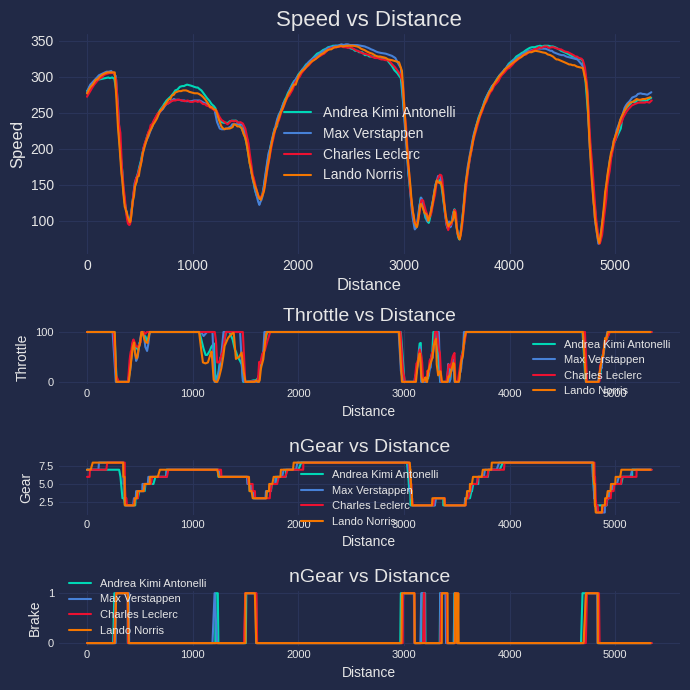

In [46]:
def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip("#")
    r, g, b = [int(hex_color[i : i + 2], 16) for i in (0, 2, 4)]
    return (r / 255, g / 255, b / 255)


def get_driver_color(driver_abbreviation):
    driver = quali.get_driver(driver_abbreviation)
    team_color = driver.TeamColor
    return hex_to_rgb(team_color)


plt.style.use("cyberpunk")

fig, ax = plt.subplots(4, 1, figsize=(7, 7), gridspec_kw={"height_ratios": [4, 1, 1, 1]})

ax[0].plot(
    tele_ant_quali.Distance, tele_ant_quali.Speed, label="Andrea Kimi Antonelli", color=get_driver_color("ANT")
)
ax[0].plot(
    tele_ver_quali.Distance, tele_ver_quali.Speed, label="Max Verstappen", color=get_driver_color("VER")
)
ax[0].plot(
    tele_lec_quali.Distance, tele_lec_quali.Speed, label="Charles Leclerc", color=get_driver_color("LEC")
)
ax[0].plot(
    tele_nor_quali.Distance, tele_nor_quali.Speed, label="Lando Norris", color=get_driver_color("NOR")
)

ax[0].set_title("Speed vs Distance", fontsize=16)
ax[0].set_xlabel("Distance", fontsize=12)
ax[0].set_ylabel("Speed", fontsize=12)
ax[0].legend(fontsize=10)
ax[0].grid(True)
ax[0].tick_params(axis="both", which="major", labelsize=10)
ax[1].plot(
    tele_ant_quali.Distance, tele_ant_quali.Throttle, label="Andrea Kimi Antonelli", color=get_driver_color("ANT")
)
ax[1].plot(
    tele_ver_quali.Distance, tele_ver_quali.Throttle, label="Max Verstappen", color=get_driver_color("VER")
)
ax[1].plot(
    tele_lec_quali.Distance, tele_lec_quali.Throttle, label="Charles Leclerc", color=get_driver_color("LEC")
)
ax[1].plot(
    tele_nor_quali.Distance, tele_nor_quali.Throttle, label="Lando Norris", color=get_driver_color("NOR")
)

ax[1].set_title("Throttle vs Distance", fontsize=14)
ax[1].set_xlabel("Distance", fontsize=10)
ax[1].set_ylabel("Throttle", fontsize=10)
ax[1].legend(fontsize=8)
ax[1].grid(True)
ax[1].tick_params(axis="both", which="major", labelsize=8)
ax[2].plot(
    tele_ant_quali.Distance, tele_ant_quali.nGear, label="Andrea Kimi Antonelli", color=get_driver_color("ANT")
)
ax[2].plot(
    tele_ver_quali.Distance, tele_ver_quali.nGear, label="Max Verstappen", color=get_driver_color("VER")
)
ax[2].plot(
    tele_lec_quali.Distance, tele_lec_quali.nGear, label="Charles Leclerc", color=get_driver_color("LEC")
)
ax[2].plot(
    tele_nor_quali.Distance, tele_nor_quali.nGear, label="Lando Norris", color=get_driver_color("NOR")
)

ax[2].set_title("nGear vs Distance", fontsize=14)
ax[2].set_xlabel("Distance", fontsize=10)
ax[2].set_ylabel("Gear", fontsize=10)
ax[2].legend(fontsize=8)
ax[2].grid(True)
ax[2].tick_params(axis="both", which="major", labelsize=8)
ax[3].plot(
    tele_ant_quali.Distance, tele_ant_quali.Brake, label="Andrea Kimi Antonelli", color=get_driver_color("ANT")
)
ax[3].plot(
    tele_ver_quali.Distance, tele_ver_quali.Brake, label="Max Verstappen", color=get_driver_color("VER")
)
ax[3].plot(
    tele_lec_quali.Distance, tele_lec_quali.Brake, label="Charles Leclerc", color=get_driver_color("LEC")
)
ax[3].plot(
    tele_nor_quali.Distance, tele_nor_quali.Brake, label="Lando Norris", color=get_driver_color("NOR")
)

ax[3].set_title("nGear vs Distance", fontsize=14)
ax[3].set_xlabel("Distance", fontsize=10)
ax[3].set_ylabel("Brake", fontsize=10)
ax[3].legend(fontsize=8)
ax[3].grid(True)
ax[3].tick_params(axis="both", which="major", labelsize=8)

plt.tight_layout()
plt.show()


In [47]:
driver1_sectors = pd.DataFrame(
    {
         "Driver": ["Andrea Kimi Antonelli"] * len(ant_quali_sec1),
        "Sector1Time": ant_quali_sec1,
        "Sector2Time": ant_quali_sec2,
        "Sector3Time": ant_quali_sec3,
        "Lap Time": ant_quali_lap_time,
    }
)


driver2_sectors = pd.DataFrame(
    {
         "Driver": ["Max Verstappen"] * len(ver_quali_sec1),
        "Sector1Time": ver_quali_sec1,
        "Sector2Time": ver_quali_sec2,
        "Sector3Time": ver_quali_sec3,
        "Lap Time": ver_quali_lap_time,
    }
)


driver3_sectors = pd.DataFrame(
    {
         "Driver": ["Charles Leclerc"] * len(lec_quali_sec1),
        "Sector1Time": lec_quali_sec1,
        "Sector2Time": lec_quali_sec2,
        "Sector3Time": lec_quali_sec3,
        "Lap Time": lec_quali_lap_time,
    }
)


driver4_sectors = pd.DataFrame(
    {
         "Driver": ["Lando Norris"] * len(nor_quali_sec1),
        "Sector1Time": nor_quali_sec1,
        "Sector2Time": nor_quali_sec2,
        "Sector3Time": nor_quali_sec3,
        "Lap Time": nor_quali_lap_time,
    }
)


all_drivers_sectors = pd.concat(
    [driver1_sectors, driver2_sectors, driver3_sectors, driver4_sectors],
    ignore_index=True,
)
all_drivers_sectors.sort_values(
    by=["Sector1Time", "Sector2Time", "Sector3Time"], ascending=True
)
all_drivers_sectors.dropna()

,Driver,Sector1Time,Sector2Time,Sector3Time,Lap Time
1,Andrea Kimi Antonelli,0 days 00:00:30.138000,0 days 00:00:33.991000,0 days 00:00:25.029000,0 days 00:01:29.158000
2,Andrea Kimi Antonelli,0 days 00:00:36.511000,0 days 00:00:47.737000,0 days 00:00:40.424000,0 days 00:02:04.672000
4,Andrea Kimi Antonelli,0 days 00:00:29.817000,0 days 00:00:34.062000,0 days 00:00:24.774000,0 days 00:01:28.653000
5,Andrea Kimi Antonelli,0 days 00:00:36.767000,0 days 00:00:40.627000,0 days 00:00:40.012000,0 days 00:01:57.406000
7,Andrea Kimi Antonelli,0 days 00:00:29.969000,0 days 00:00:33.555000,0 days 00:00:24.828000,0 days 00:01:28.352000
8,Andrea Kimi Antonelli,0 days 00:00:34.704000,0 days 00:00:39.196000,0 days 00:00:35.968000,0 days 00:01:49.868000
10,Andrea Kimi Antonelli,0 days 00:00:29.879000,0 days 00:00:33.658000,0 days 00:00:24.752000,0 days 00:01:28.289000
11,Andrea Kimi Antonelli,0 days 00:00:40.928000,0 days 00:00:41.371000,0 days 00:01:13.673000,0 days 00:02:35.972000
13,Andrea Kimi Antonelli,0 days 00:00:29.743000,0 days 00:00:33.431000,0 days 00:00:24.624000,0 days 00:01:27.798000
14,Andrea Kimi Antonelli,0 days 00:00:33.955000,0 days 00:00:37.286000,0 days 00:00:37.730000,0 days 00:01:48.971000


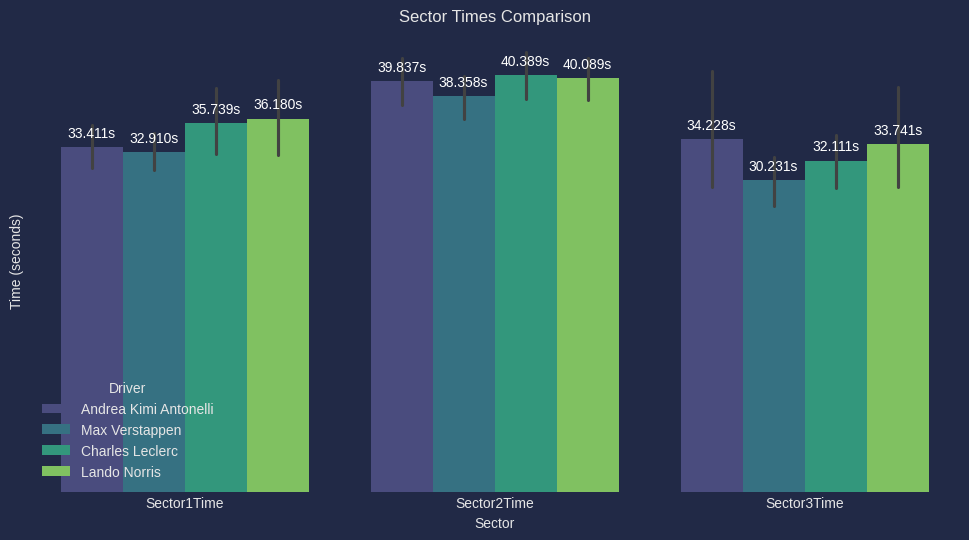

In [48]:
melted_data = all_drivers_sectors.melt(
    id_vars=["Driver"],
    value_vars=["Sector1Time", "Sector2Time", "Sector3Time"],
    var_name="Sector",
    value_name="Time",
)

melted_data["Time"] = melted_data["Time"].dt.total_seconds()

plt.figure(figsize=(12, 6))

bar_plot = sns.barplot(
    data=melted_data, x="Sector", y="Time", hue="Driver", palette="viridis"
)

for p in bar_plot.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        bar_plot.annotate(
            f"{height:.3f}s",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
        va="bottom",
            fontsize=10,
            color="white",
            xytext=(0, 5),
            textcoords="offset points",
        )

plt.title("Sector Times Comparison")
plt.ylabel("Time (seconds)")
plt.xlabel("Sector")
plt.gca().set_yticks([])
plt.show()

*Race*

In [49]:
race = f1.get_session(2026, "Miami", "R")
race.load()

core           INFO 	Loading data for Miami Grand Prix - Race [v3.8.1]


req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data


req            INFO 	Using cached data for lap_count


...

req            INFO 	Using cached data for position_data


req            INFO 	Using cached data for weather_data


req            INFO 	Using cached data for race_control_messages


core        WARNING 	Driver 12 completed the race distance 00:00.027000 before the recorded end of the session.


core           INFO 	Finished loading data for 22 drivers: ['12', '1', '81', '63', '3', '44', '43', '16', '55', '23', '87', '5', '31', '41', '14', '11', '18', '77', '27', '30', '10', '6']


In [50]:
race.session_info

{'Meeting': {'Key': 1284,
  'Name': 'Miami Grand Prix',
  'OfficialName': 'FORMULA 1 CRYPTO.COM MIAMI GRAND PRIX 2026',
  'Location': 'Miami Gardens',
  'Number': 4,
  'Country': {'Key': 19, 'Code': 'USA', 'Name': 'United States'},
  'Circuit': {'Key': 151, 'ShortName': 'Miami'}},
 'SessionStatus': 'Inactive',
 'ArchiveStatus': {'Status': 'Generating'},
 'Key': 11280,
 'Type': 'Race',
 'Name': 'Race',
 'StartDate': datetime.datetime(2026, 5, 3, 13, 0),
 'EndDate': datetime.datetime(2026, 5, 3, 15, 0),
 'GmtOffset': datetime.timedelta(days=-1, seconds=72000),
 'Path': '2026/2026-05-03_Miami_Grand_Prix/2026-05-03_Race/'}

In [51]:
race.results.loc[
    :, ["Abbreviation", "TeamName", "GridPosition", "Position", "Time", "Status"]
]

,Abbreviation,TeamName,GridPosition,Position,Time,Status
12,ANT,Mercedes,1.0,1.0,0 days 01:33:19.273000,Finished
1,NOR,McLaren,4.0,2.0,0 days 00:00:03.264000,Finished
81,PIA,McLaren,7.0,3.0,0 days 00:00:27.092000,Finished
63,RUS,Mercedes,5.0,4.0,0 days 00:00:43.051000,Finished
3,VER,Red Bull Racing,2.0,5.0,0 days 00:00:48.949000,Finished
44,HAM,Ferrari,6.0,6.0,0 days 00:00:53.753000,Finished
43,COL,Alpine,8.0,7.0,0 days 00:01:01.871000,Finished
16,LEC,Ferrari,3.0,8.0,0 days 00:01:04.245000,Finished
55,SAI,Williams,13.0,9.0,0 days 00:01:22.072000,Finished
23,ALB,Williams,15.0,10.0,0 days 00:01:30.972000,Finished


In [52]:
race_laps = race.laps
race_laps

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:59:00.108000,NOR,1,0 days 00:01:38.115000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:34.453000,...,True,McLaren,0 days 00:57:21.749000,2026-05-03 17:04:02.494,1,3.0,False,,False,False
1,0 days 01:00:32.878000,NOR,1,0 days 00:01:32.770000,2.0,1.0,NaT,NaT,0 days 00:00:32.593000,0 days 00:00:34.600000,...,True,McLaren,0 days 00:59:00.108000,2026-05-03 17:05:40.853,1,3.0,False,,False,True
2,0 days 01:02:06.141000,NOR,1,0 days 00:01:33.263000,3.0,1.0,NaT,NaT,0 days 00:00:32.816000,0 days 00:00:34.702000,...,True,McLaren,0 days 01:00:32.878000,2026-05-03 17:07:13.623,1,3.0,False,,False,True
3,0 days 01:03:39.955000,NOR,1,0 days 00:01:33.814000,4.0,1.0,NaT,NaT,0 days 00:00:33.089000,0 days 00:00:34.864000,...,True,McLaren,0 days 01:02:06.141000,2026-05-03 17:08:46.886,1,3.0,False,,False,True
4,0 days 01:05:13.797000,NOR,1,0 days 00:01:33.842000,5.0,1.0,NaT,NaT,0 days 00:00:32.883000,0 days 00:00:35.214000,...,True,McLaren,0 days 01:03:39.955000,2026-05-03 17:10:20.700,12,3.0,False,,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035,0 days 02:24:27.485000,BEA,87,0 days 00:01:34.720000,52.0,2.0,NaT,NaT,0 days 00:00:33.114000,0 days 00:00:35.561000,...,True,Haas F1 Team,0 days 02:22:52.765000,2026-05-03 18:29:33.510,1,11.0,False,,False,True
1036,0 days 02:26:01.841000,BEA,87,0 days 00:01:34.356000,53.0,2.0,NaT,NaT,0 days 00:00:33.070000,0 days 00:00:35.390000,...,True,Haas F1 Team,0 days 02:24:27.485000,2026-05-03 18:31:08.230,1,11.0,False,,False,True
1037,0 days 02:27:37.256000,BEA,87,0 days 00:01:35.415000,54.0,2.0,NaT,NaT,0 days 00:00:32.943000,0 days 00:00:36.504000,...,True,Haas F1 Team,0 days 02:26:01.841000,2026-05-03 18:32:42.586,1,11.0,False,,False,True
1038,0 days 02:29:13.152000,BEA,87,0 days 00:01:35.896000,55.0,2.0,NaT,NaT,0 days 00:00:34.829000,0 days 00:00:35.118000,...,True,Haas F1 Team,0 days 02:27:37.256000,2026-05-03 18:34:18.001,1,11.0,False,,False,True


In [53]:
ant_race_laps = race.laps.pick_driver("ANT")
fastest_lap_ant_race = ant_race_laps.pick_fastest().LapTime
ant_race_lap_time = ant_race_laps["LapTime"]
ant_race_sec1 = ant_race_laps["Sector1Time"]
ant_race_sec2 = ant_race_laps["Sector2Time"]
ant_race_sec3 = ant_race_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(fastest_lap_ant_race), "which was in Lap number" ,ant_race_laps.pick_fastest().LapNumber)
ant_race_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:31.968000 which was in Lap number 34.0


/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
118,0 days 00:01:37.243000,NaT,0 days 00:00:34.209000,0 days 00:00:25.710000,213.0,189.0,267.0,311.0
119,0 days 00:01:32.936000,0 days 00:00:32.563000,0 days 00:00:34.481000,0 days 00:00:25.892000,211.0,188.0,259.0,316.0
120,0 days 00:01:33.224000,0 days 00:00:32.814000,0 days 00:00:34.577000,0 days 00:00:25.833000,210.0,186.0,263.0,310.0
121,0 days 00:01:33.586000,0 days 00:00:32.729000,0 days 00:00:35.095000,0 days 00:00:25.762000,212.0,184.0,283.0,303.0
122,0 days 00:01:34.602000,0 days 00:00:32.893000,0 days 00:00:35.572000,0 days 00:00:26.137000,209.0,186.0,257.0,313.0


In [54]:
fastest_lap_ant_race = ant_race_laps.pick_fastest()
tele_ant_race = fastest_lap_ant_race.get_telemetry().add_distance()
speed_ant_race = tele_ant_race.Speed
tele_ant_race.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,277.457143,7,10714.057143
3,277.882143,7,10738.282156
4,278.000000,7,10745.000000
5,279.000000,7,10782.000000
6,279.372223,7,10793.911122
...,...,...,...
665,272.891667,7,10545.833344
666,274.000000,7,10568.000000
667,274.167857,7,10581.932162
668,275.000000,7,10651.000000


In [55]:
nor_race_laps = race.laps.pick_driver("NOR")
fastest_lap_nor_race = nor_race_laps.pick_fastest().LapTime
nor_race_lap_time = nor_race_laps["LapTime"]
nor_race_sec1 = nor_race_laps["Sector1Time"]
nor_race_sec2 = nor_race_laps["Sector2Time"]
nor_race_sec3 = nor_race_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(fastest_lap_nor_race), "which was in Lap number" ,nor_race_laps.pick_fastest().LapNumber)
nor_race_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:31.869000 which was in Lap number 35.0


/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
0,0 days 00:01:38.115000,NaT,0 days 00:00:34.453000,0 days 00:00:25.729000,213.0,183.0,273.0,298.0
1,0 days 00:01:32.770000,0 days 00:00:32.593000,0 days 00:00:34.600000,0 days 00:00:25.577000,211.0,184.0,271.0,317.0
2,0 days 00:01:33.263000,0 days 00:00:32.816000,0 days 00:00:34.702000,0 days 00:00:25.745000,209.0,185.0,270.0,313.0
3,0 days 00:01:33.814000,0 days 00:00:33.089000,0 days 00:00:34.864000,0 days 00:00:25.861000,205.0,186.0,273.0,310.0
4,0 days 00:01:33.842000,0 days 00:00:32.883000,0 days 00:00:35.214000,0 days 00:00:25.745000,210.0,183.0,281.0,308.0


In [56]:
fastest_lap_nor_race = nor_race_laps.pick_fastest()
tele_nor_race = fastest_lap_nor_race.get_telemetry().add_distance()
speed_nor_race = tele_nor_race.Speed
tele_nor_race.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,286.247500,8,10478.989998
3,287.852500,8,10485.410002
4,289.000000,8,10490.000000
5,289.000000,8,10518.050010
6,289.000000,8,10526.000000
...,...,...,...
690,283.000000,8,10355.000000
691,284.592308,8,10418.692327
692,286.284616,8,10486.384635
693,287.000000,8,10515.000000


In [57]:
rus_race_laps = race.laps.pick_driver("RUS")
fastest_lap_rus_race = rus_race_laps.pick_fastest().LapTime
rus_race_lap_time = rus_race_laps["LapTime"]
rus_race_sec1 = rus_race_laps["Sector1Time"]
rus_race_sec2 = rus_race_laps["Sector2Time"]
rus_race_sec3 = rus_race_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(fastest_lap_rus_race), "which was in Lap number" ,rus_race_laps.pick_fastest().LapNumber)
rus_race_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:32.446000 which was in Lap number 53.0


/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
815,0 days 00:01:39.258000,NaT,0 days 00:00:34.730000,0 days 00:00:25.557000,213.0,186.0,257.0,331.0
816,0 days 00:01:33.194000,0 days 00:00:33.022000,0 days 00:00:34.637000,0 days 00:00:25.535000,213.0,187.0,283.0,322.0
817,0 days 00:01:33.574000,0 days 00:00:32.852000,0 days 00:00:34.905000,0 days 00:00:25.817000,213.0,186.0,263.0,317.0
818,0 days 00:01:33.873000,0 days 00:00:32.893000,0 days 00:00:34.913000,0 days 00:00:26.067000,212.0,186.0,263.0,313.0
819,0 days 00:01:33.837000,0 days 00:00:32.666000,0 days 00:00:35.055000,0 days 00:00:26.116000,211.0,186.0,259.0,316.0


In [58]:
fastest_lap_rus_race = rus_race_laps.pick_fastest()
tele_rus_race = fastest_lap_rus_race.get_telemetry().add_distance()
speed_rus_race = tele_rus_race.Speed
tele_rus_race.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,288.351135,7,11120.371543
3,288.470454,7,11124.138604
4,290.061363,7,11174.365877
5,291.000000,7,11204.000000
6,291.000000,7,11209.774982
...,...,...,...
715,283.000000,7,11010.000000
716,283.014285,7,11010.157133
717,284.157142,7,11022.728561
718,285.000000,7,11032.000000


In [59]:
ver_race_laps = race.laps.pick_driver("VER")
fastest_lap_ver_race = ver_race_laps.pick_fastest().LapTime
ver_race_lap_time = ver_race_laps["LapTime"]
ver_race_sec1 = ver_race_laps["Sector1Time"]
ver_race_sec2 = ver_race_laps["Sector2Time"]
ver_race_sec3 = ver_race_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(fastest_lap_ver_race), "which was in Lap number" ,ver_race_laps.pick_fastest().LapNumber)
ver_race_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:33.110000 which was in Lap number 24.0


/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
408,0 days 00:01:44.911000,NaT,0 days 00:00:36.327000,0 days 00:00:27.361000,207.0,173.0,247.0,306.0
409,0 days 00:01:33.464000,0 days 00:00:32.940000,0 days 00:00:34.738000,0 days 00:00:25.786000,214.0,186.0,260.0,310.0
410,0 days 00:01:33.239000,0 days 00:00:32.585000,0 days 00:00:34.865000,0 days 00:00:25.789000,211.0,185.0,262.0,313.0
411,0 days 00:01:33.536000,0 days 00:00:32.735000,0 days 00:00:34.937000,0 days 00:00:25.864000,210.0,184.0,261.0,313.0
412,0 days 00:01:34.090000,0 days 00:00:32.980000,0 days 00:00:35.120000,0 days 00:00:25.990000,212.0,184.0,239.0,314.0


In [60]:
fastest_lap_ver_race = ver_race_laps.pick_fastest()
tele_ver_race = fastest_lap_ver_race.get_telemetry().add_distance()
speed_ver_race = tele_ver_race.Speed
tele_ver_race.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,268.895833,7,10754.979143
3,269.000000,7,10758.000000
4,269.708333,7,10804.749965
5,270.000000,7,10824.000000
6,271.699999,7,10851.199980
...,...,...,...
705,267.000000,7,10674.000000
706,267.031250,7,10676.937462
707,267.968750,7,10765.062462
708,268.000000,7,10768.000000


In [61]:
driver1_sectors = pd.DataFrame(
    {
         "Driver": ["Andrea Kimi Antonelli"] * len(ant_race_sec1),
        "Sector1Time": ant_race_sec1,
        "Sector2Time": ant_race_sec2,
        "Sector3Time": ant_race_sec3,
        "Lap Time": ant_race_lap_time,
    }
)


driver2_sectors = pd.DataFrame(
    {
         "Driver": ["Lando Norris"] * len(nor_race_sec1),
        "Sector1Time": nor_race_sec1,
        "Sector2Time": nor_race_sec2,
        "Sector3Time": nor_race_sec3,
        "Lap Time": nor_race_lap_time,
    }
)


driver3_sectors = pd.DataFrame(
    {
         "Driver": ["George Russell"] * len(rus_race_sec1),
        "Sector1Time": rus_race_sec1,
        "Sector2Time": rus_race_sec2,
        "Sector3Time": rus_race_sec3,
        "Lap Time": rus_race_lap_time,
    }
)


driver4_sectors = pd.DataFrame(
    {
         "Driver": ["Max Verstappen"] * len(ver_race_sec1),
        "Sector1Time": ver_race_sec1,
        "Sector2Time": ver_race_sec2,
        "Sector3Time": ver_race_sec3,
        "Lap Time": ver_race_lap_time,
    }
)


all_drivers_sectors = pd.concat(
    [driver1_sectors, driver2_sectors, driver3_sectors, driver4_sectors],
    ignore_index=True,
)
all_drivers_sectors.sort_values(
    by=["Sector1Time", "Sector2Time", "Sector3Time"], ascending=True
)
all_drivers_sectors.dropna()

,Driver,Sector1Time,Sector2Time,Sector3Time,Lap Time
1,Andrea Kimi Antonelli,0 days 00:00:32.563000,0 days 00:00:34.481000,0 days 00:00:25.892000,0 days 00:01:32.936000
2,Andrea Kimi Antonelli,0 days 00:00:32.814000,0 days 00:00:34.577000,0 days 00:00:25.833000,0 days 00:01:33.224000
3,Andrea Kimi Antonelli,0 days 00:00:32.729000,0 days 00:00:35.095000,0 days 00:00:25.762000,0 days 00:01:33.586000
4,Andrea Kimi Antonelli,0 days 00:00:32.893000,0 days 00:00:35.572000,0 days 00:00:26.137000,0 days 00:01:34.602000
5,Andrea Kimi Antonelli,0 days 00:00:41.747000,0 days 00:00:51.819000,0 days 00:00:38.527000,0 days 00:02:12.093000
...,...,...,...,...,...
223,Max Verstappen,0 days 00:00:32.605000,0 days 00:00:35.153000,0 days 00:00:26.115000,0 days 00:01:33.873000
224,Max Verstappen,0 days 00:00:32.642000,0 days 00:00:35.278000,0 days 00:00:26.323000,0 days 00:01:34.243000
225,Max Verstappen,0 days 00:00:33.478000,0 days 00:00:35.839000,0 days 00:00:26.556000,0 days 00:01:35.873000
226,Max Verstappen,0 days 00:00:32.976000,0 days 00:00:35.948000,0 days 00:00:26.653000,0 days 00:01:35.577000


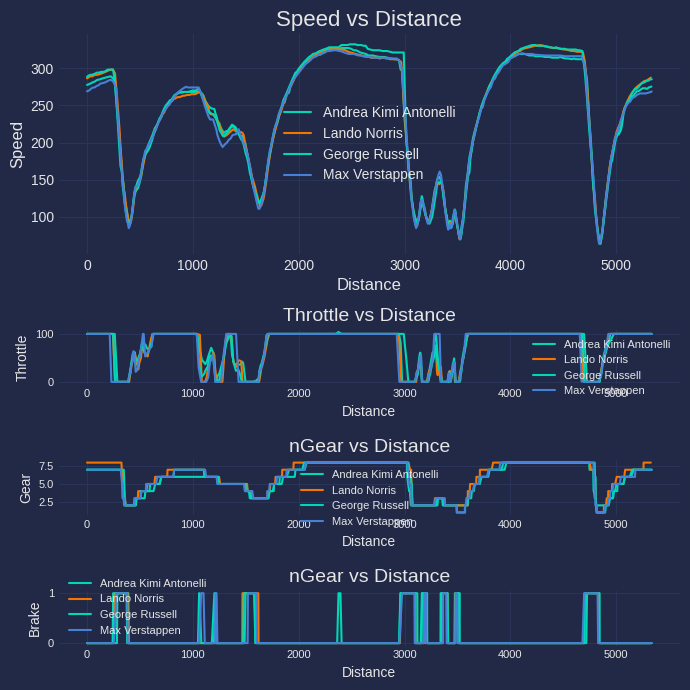

In [62]:
def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip("#")
    r, g, b = [int(hex_color[i : i + 2], 16) for i in (0, 2, 4)]
    return (r / 255, g / 255, b / 255)


def get_driver_color(driver_abbreviation):
    driver = race.get_driver(driver_abbreviation)
    team_color = driver.TeamColor
    return hex_to_rgb(team_color)


plt.style.use("cyberpunk")

fig, ax = plt.subplots(4, 1, figsize=(7, 7), gridspec_kw={"height_ratios": [4, 1, 1, 1]})

ax[0].plot(
    tele_ant_race.Distance, tele_ant_race.Speed, label="Andrea Kimi Antonelli", color=get_driver_color("ANT")
)
ax[0].plot(
    tele_nor_race.Distance, tele_nor_race.Speed, label="Lando Norris", color=get_driver_color("NOR")
)
ax[0].plot(
    tele_rus_race.Distance, tele_rus_race.Speed, label="George Russell", color=get_driver_color("RUS")
)
ax[0].plot(
    tele_ver_race.Distance, tele_ver_race.Speed, label="Max Verstappen", color=get_driver_color("VER")
)

ax[0].set_title("Speed vs Distance", fontsize=16)
ax[0].set_xlabel("Distance", fontsize=12)
ax[0].set_ylabel("Speed", fontsize=12)
ax[0].legend(fontsize=10)
ax[0].grid(True)
ax[0].tick_params(axis="both", which="major", labelsize=10)
ax[1].plot(
    tele_ant_race.Distance, tele_ant_race.Throttle, label="Andrea Kimi Antonelli", color=get_driver_color("ANT")
)
ax[1].plot(
    tele_nor_race.Distance, tele_nor_race.Throttle, label="Lando Norris", color=get_driver_color("NOR")
)
ax[1].plot(
    tele_rus_race.Distance, tele_rus_race.Throttle, label="George Russell", color=get_driver_color("RUS")
)
ax[1].plot(
    tele_ver_race.Distance, tele_ver_race.Throttle, label="Max Verstappen", color=get_driver_color("VER")
)

ax[1].set_title("Throttle vs Distance", fontsize=14)
ax[1].set_xlabel("Distance", fontsize=10)
ax[1].set_ylabel("Throttle", fontsize=10)
ax[1].legend(fontsize=8)
ax[1].grid(True)
ax[1].tick_params(axis="both", which="major", labelsize=8)
ax[2].plot(
    tele_ant_race.Distance, tele_ant_race.nGear, label="Andrea Kimi Antonelli", color=get_driver_color("ANT")
)
ax[2].plot(
    tele_nor_race.Distance, tele_nor_race.nGear, label="Lando Norris", color=get_driver_color("NOR")
)
ax[2].plot(
    tele_rus_race.Distance, tele_rus_race.nGear, label="George Russell", color=get_driver_color("RUS")
)
ax[2].plot(
    tele_ver_race.Distance, tele_ver_race.nGear, label="Max Verstappen", color=get_driver_color("VER")
)

ax[2].set_title("nGear vs Distance", fontsize=14)
ax[2].set_xlabel("Distance", fontsize=10)
ax[2].set_ylabel("Gear", fontsize=10)
ax[2].legend(fontsize=8)
ax[2].grid(True)
ax[2].tick_params(axis="both", which="major", labelsize=8)
ax[3].plot(
    tele_ant_race.Distance, tele_ant_race.Brake, label="Andrea Kimi Antonelli", color=get_driver_color("ANT")
)
ax[3].plot(
    tele_nor_race.Distance, tele_nor_race.Brake, label="Lando Norris", color=get_driver_color("NOR")
)
ax[3].plot(
    tele_rus_race.Distance, tele_rus_race.Brake, label="George Russell", color=get_driver_color("RUS")
)
ax[3].plot(
    tele_ver_race.Distance, tele_ver_race.Brake, label="Max Verstappen", color=get_driver_color("VER")
)

ax[3].set_title("nGear vs Distance", fontsize=14)
ax[3].set_xlabel("Distance", fontsize=10)
ax[3].set_ylabel("Brake", fontsize=10)
ax[3].legend(fontsize=8)
ax[3].grid(True)
ax[3].tick_params(axis="both", which="major", labelsize=8)

plt.tight_layout()
plt.show()


In [63]:
driver1_sectors = pd.DataFrame(
    {
         "Driver": ["Andrea Kimi Antonelli"] * len(ant_race_sec1),
        "Sector1Time": ant_race_sec1,
        "Sector2Time": ant_race_sec2,
        "Sector3Time": ant_race_sec3,
        "Lap Time": ant_race_lap_time,
    }
)


driver2_sectors = pd.DataFrame(
    {
         "Driver": ["Lando Norris"] * len(nor_race_sec1),
        "Sector1Time": nor_race_sec1,
        "Sector2Time": nor_race_sec2,
        "Sector3Time": nor_race_sec3,
        "Lap Time": nor_race_lap_time,
    }
)


driver3_sectors = pd.DataFrame(
    {
         "Driver": ["George Russell"] * len(rus_race_sec1),
        "Sector1Time": rus_race_sec1,
        "Sector2Time": rus_race_sec2,
        "Sector3Time": rus_race_sec3,
        "Lap Time": rus_race_lap_time,
    }
)


driver4_sectors = pd.DataFrame(
    {
         "Driver": ["Max Verstappen"] * len(ver_race_sec1),
        "Sector1Time": ver_race_sec1,
        "Sector2Time": ver_race_sec2,
        "Sector3Time": ver_race_sec3,
        "Lap Time": ver_race_lap_time,
    }
)


all_drivers_sectors = pd.concat(
    [driver1_sectors, driver2_sectors, driver3_sectors, driver4_sectors],
    ignore_index=True,
)
all_drivers_sectors.sort_values(
    by=["Sector1Time", "Sector2Time", "Sector3Time"], ascending=True
)
all_drivers_sectors.dropna()

,Driver,Sector1Time,Sector2Time,Sector3Time,Lap Time
1,Andrea Kimi Antonelli,0 days 00:00:32.563000,0 days 00:00:34.481000,0 days 00:00:25.892000,0 days 00:01:32.936000
2,Andrea Kimi Antonelli,0 days 00:00:32.814000,0 days 00:00:34.577000,0 days 00:00:25.833000,0 days 00:01:33.224000
3,Andrea Kimi Antonelli,0 days 00:00:32.729000,0 days 00:00:35.095000,0 days 00:00:25.762000,0 days 00:01:33.586000
4,Andrea Kimi Antonelli,0 days 00:00:32.893000,0 days 00:00:35.572000,0 days 00:00:26.137000,0 days 00:01:34.602000
5,Andrea Kimi Antonelli,0 days 00:00:41.747000,0 days 00:00:51.819000,0 days 00:00:38.527000,0 days 00:02:12.093000
...,...,...,...,...,...
223,Max Verstappen,0 days 00:00:32.605000,0 days 00:00:35.153000,0 days 00:00:26.115000,0 days 00:01:33.873000
224,Max Verstappen,0 days 00:00:32.642000,0 days 00:00:35.278000,0 days 00:00:26.323000,0 days 00:01:34.243000
225,Max Verstappen,0 days 00:00:33.478000,0 days 00:00:35.839000,0 days 00:00:26.556000,0 days 00:01:35.873000
226,Max Verstappen,0 days 00:00:32.976000,0 days 00:00:35.948000,0 days 00:00:26.653000,0 days 00:01:35.577000


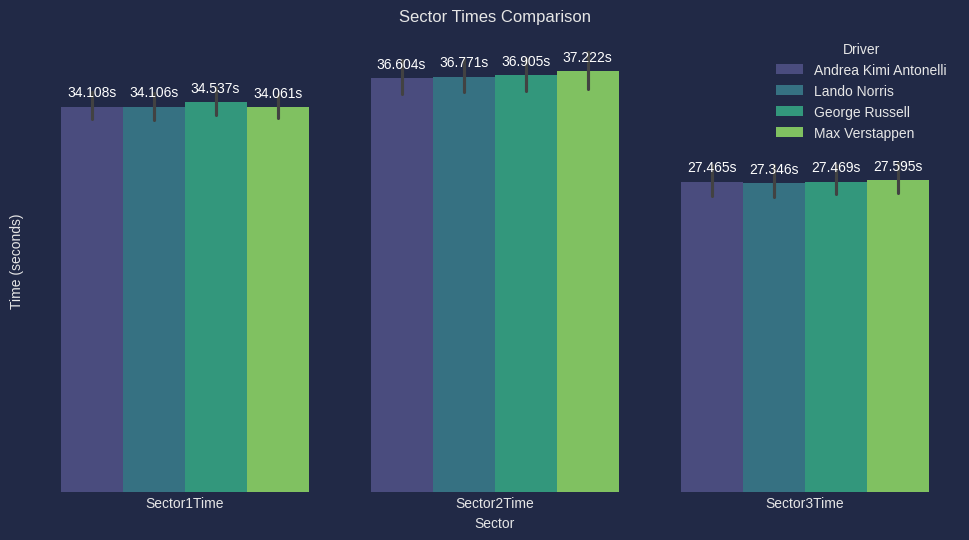

In [64]:
melted_data = all_drivers_sectors.melt(
    id_vars=["Driver"],
    value_vars=["Sector1Time", "Sector2Time", "Sector3Time"],
    var_name="Sector",
    value_name="Time",
)

melted_data["Time"] = melted_data["Time"].dt.total_seconds()

plt.figure(figsize=(12, 6))

bar_plot = sns.barplot(
    data=melted_data, x="Sector", y="Time", hue="Driver", palette="viridis"
)

for p in bar_plot.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        bar_plot.annotate(
            f"{height:.3f}s",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
        va="bottom",
            fontsize=10,
            color="white",
            xytext=(0, 5),
            textcoords="offset points",
        )

plt.title("Sector Times Comparison")
plt.ylabel("Time (seconds)")
plt.xlabel("Sector")
plt.gca().set_yticks([])
plt.show()

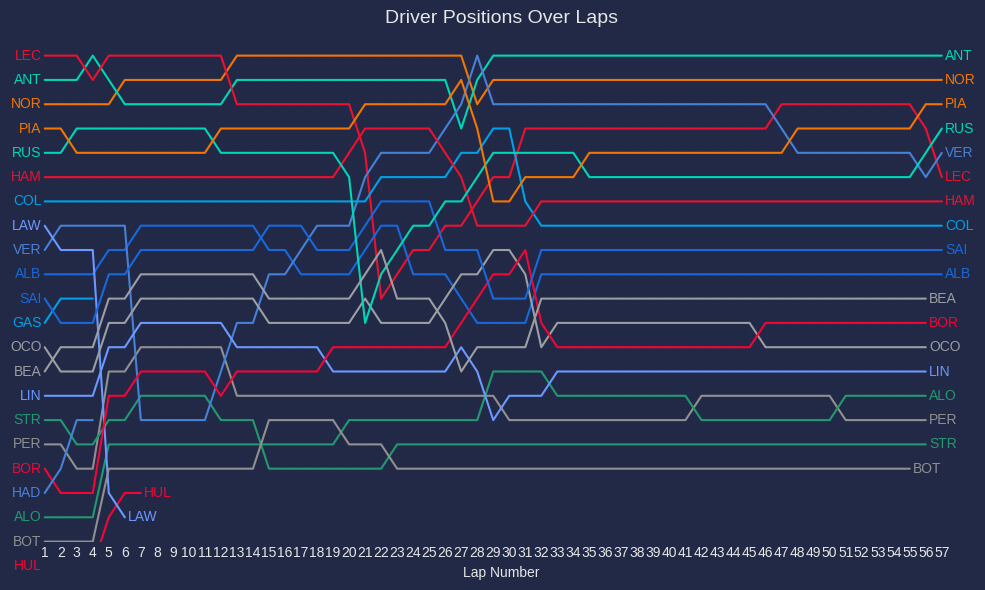

In [65]:
drivers = race.laps.Driver.unique()
drivers_ab = drivers.tolist()
nlaps = int(race.laps.LapNumber.unique().max())

team_colors = {}

for driver in drivers_ab:
    driver_object = race.get_driver(driver)
    hex_color = driver_object.TeamColor
    team_colors[driver] = hex_to_rgb(hex_color)

plt.figure(figsize=(10, 6))
for driver in drivers_ab:
    positions = race_laps[race_laps['Driver'] == driver]['Position'].values  
    color = team_colors.get(driver, (0.5, 0.5, 0.5))
    plt.plot(range(1, len(positions) + 1), positions, label=driver, color=color)
    
    plt.text(
        1 - 0.2,
        positions[0],
        driver,
        color=color,
        fontsize=10,
        verticalalignment='center',
        horizontalalignment='right'
    )
    
    plt.text(
        len(positions) + 0.2,
        positions[-1],
        driver,
        color=color,
        fontsize=10,
        verticalalignment='center',
        horizontalalignment='left'
    )

plt.title("Driver Positions Over Laps", fontsize=14)
plt.grid(True, linestyle=':', alpha=0.5)
plt.xlim(0.5, float(nlaps) + 1.5)
plt.xlabel("Lap Number")
plt.ylim(0, 21)
plt.gca().invert_yaxis()
plt.gca().set_yticks([])
plt.xticks(range(1, nlaps + 1))
plt.tight_layout()
plt.show()

/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
 

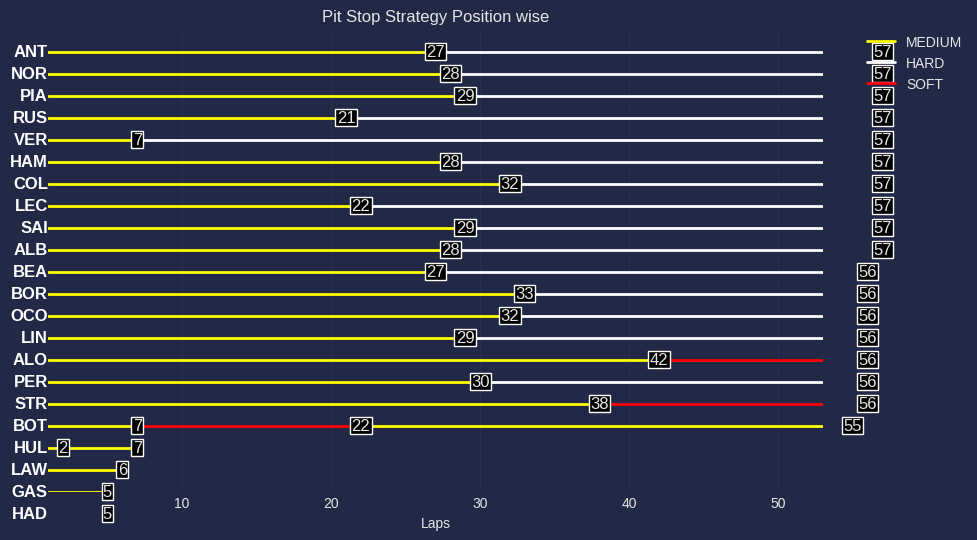

In [66]:
def getDriverPosition(abbreviation: str):
    res = race.results
    abbr = res["Abbreviation"] == abbreviation
    pos = res.loc[abbr, ["Position"]]
    posi = pos.iloc[-1]
    return int(posi.iloc[0])


def getCompound(abbreviation: str):
    driver_race = race.laps.pick_driver(abbreviation)
    lastLap = driver_race.LapNumber.count()
    if driver_race["TyreLife"].iloc[0] == 1.0:
        condition = driver_race["TyreLife"] == 1
        driver_comp = driver_race.loc[condition, ["Compound", "LapNumber"]]
        compound = driver_comp.Compound.tolist()
        return compound, driver_comp, lastLap
    else:
        compound = []
        result = []
        for i in range(0, len(driver_race["TyreLife"])):
            if driver_race["TyreLife"].iloc[i] < driver_race["TyreLife"].iloc[i - 1]:
                result.append(
                    {
                        "Compound": driver_race["Compound"].iloc[i],
                        "LapNumber": driver_race["LapNumber"].iloc[i],
                    }
                )
                compound.append(driver_race["Compound"].iloc[i])

        driver_comp = pd.DataFrame(result)
        return compound, driver_comp, lastLap


fig, ax = plt.subplots(figsize=(10, 6))

color_mapping = {
    "MEDIUM": "yellow",
    "SOFT": "red",
    "HARD": "white",
    "INTERMEDIATE": "green",
    "WET": "blue",
}
drivers = race.laps.Driver.unique()
drivers_ab = drivers.tolist()
used_labels = set()
for driver in drivers_ab:
    compound, driver_comp, lastLap = getCompound(driver)

    list1 = driver_comp.LapNumber.tolist()
    list1.append(lastLap)
    int_list = [int(x) for x in list1]
    x_points = int_list
    n = len(int_list)
    posi = getDriverPosition(driver)
    y_points = [posi] * n

    for i in range(len(driver_comp.LapNumber)):
        x_segment = [x_points[i], x_points[i + 1]]
        y_segment = [y_points[i], y_points[i + 1]]
        tire_color = color_mapping.get(compound[i], "#000000")
        label = compound[i] if compound[i] not in used_labels else None
        
        ax.plot(x_segment, y_segment, color=tire_color, linewidth=2, label=label)
        used_labels.add(compound[i])

        ax.text(
            x_points[i + 1],
            y_points[i + 1],
            str(x_points[i + 1]),
            fontsize=12,
            ha="center",
            va="center",
            bbox=dict(facecolor="black", edgecolor="white", pad=1),
        )
        ax.annotate(f'{i}',
                xy=(0, 1),
                xytext=(-10, 0),
                textcoords='offset points',
                va='center',
                ha='right',
                color="white",
                fontweight='bold')
    ax.text(
        x_points[0], 
        y_points[0], 
        driver, 
        fontsize=12, 
        ha='right', 
        va='center', 
        color="white", 
        fontweight='bold',
    )
    
ax.set_xlim(1, 53)
ax.invert_yaxis()
ax.set_ylim(21, 0)
ax.set_title("Pit Stop Strategy Position wise")
ax.set_xlabel("Laps")
plt.gca().set_yticks([])
ax.axvline(x=0, color='black', linewidth=2)
ax.grid(True, linestyle="-", alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)
plt.show()

In [67]:
res = race.results
drivers = res['Abbreviation'].tolist()
fastest_speed = pd.DataFrame(columns=['Driver', 'Speed'])
for i in drivers:
    tele = race.laps.pick_driver(i)
    speed = tele.SpeedST.max()
    df = pd.DataFrame({'Driver': [i], 'Speed': [speed]})
    fastest_speed = pd.concat([fastest_speed, df], ignore_index=True)
fastest_speed.sort_values(by="Speed",ascending=True)


/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/tmp/ipykernel_52416/905247657.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  fastest_speed = pd.concat([fastest_speed, df], ignore_index=True)


,Driver,Speed
18,HUL,300.0
17,BOT,308.0
19,LAW,310.0
15,PER,318.0
13,LIN,319.0
11,BOR,319.0
20,GAS,320.0
7,LEC,322.0
8,SAI,322.0
2,PIA,323.0


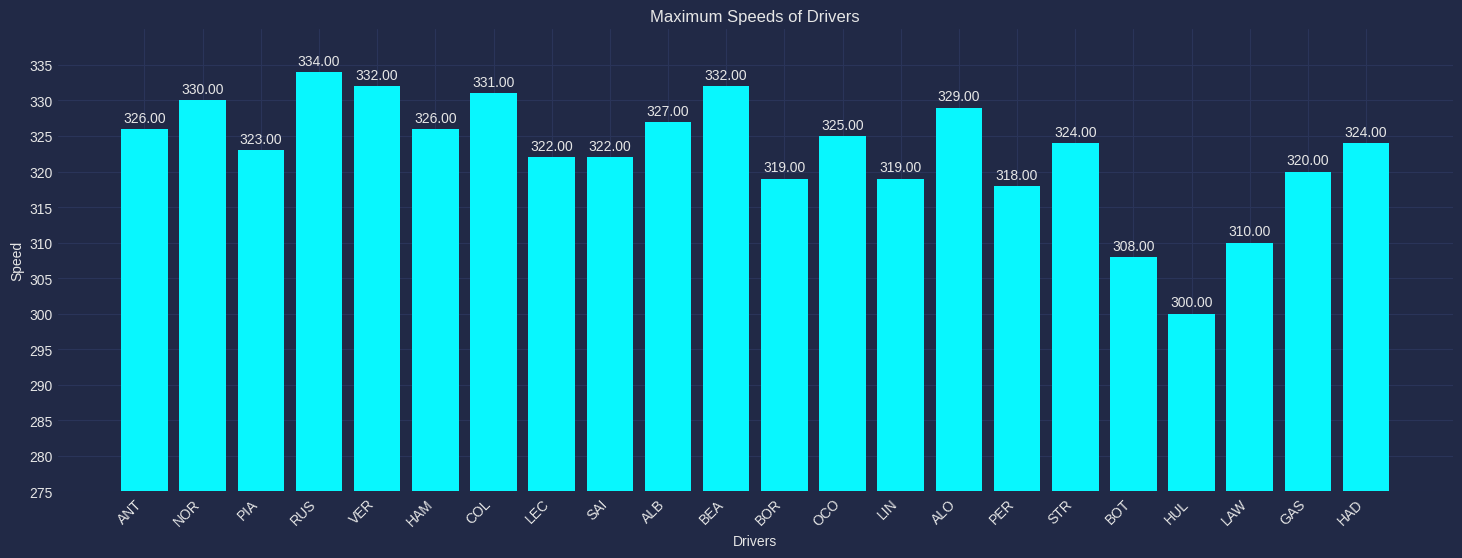

In [68]:
fig,ax = plt.subplots(figsize=(18, 6))
bars = ax.bar(fastest_speed['Driver'], fastest_speed['Speed'])
ax.set_xlabel('Drivers')
ax.set_ylabel('Speed')
ax.set_title('Maximum Speeds of Drivers')
plt.xticks(rotation=45, ha='right')

y_min = 275
y_max = np.ceil(fastest_speed['Speed'].max() / 5) * 5 + 5
y_ticks = np.arange(y_min, y_max, 5)
ax.set_ylim(y_min, y_max)
ax.set_yticks(y_ticks)

for bar in bars:
    height = bar.get_height()
    ax.annotate('{:.2f}'.format(height),
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.show()

*Pace Comparison*

In [69]:
plotting.setup_mpl()

In [70]:
laps_ver = race_laps.pick_driver("VER")
laps_nor = race_laps.pick_driver("NOR")

fastest_ver = laps_ver.pick_fastest().get_telemetry().add_distance()
fastest_nor = laps_nor.pick_fastest().get_telemetry().add_distance()

fastest_ver["Driver"] = "VER"
fastest_nor["Driver"] = "NOR"
telemetry = pd.concat([fastest_ver,fastest_nor])

/home/hexa/Coding/F1/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


In [71]:
num_minisectors = 25
total_distance = total_distance = max(telemetry['Distance'])
minisector_length = total_distance / num_minisectors
minisectors = [0]
for i in range(0, (num_minisectors - 1)):
    minisectors.append(minisector_length * (i + 1))
telemetry['Minisector'] = telemetry['Distance'].apply(
    lambda dist: (
        int((dist // minisector_length) + 1)
    )
)

In [72]:
average_speed = telemetry.groupby(['Minisector', 'Driver'])['Speed'].mean().reset_index()
average_speed

,Minisector,Driver,Speed
0,1,NOR,291.656032
1,1,VER,276.028776
2,2,NOR,160.329487
3,2,VER,147.998519
4,3,NOR,161.862127
5,3,VER,166.976384
6,4,NOR,242.167181
7,4,VER,244.439689
8,5,NOR,264.003751
9,5,VER,273.206108


In [73]:
fastest_driver = average_speed.loc[average_speed.groupby(['Minisector'])['Speed'].idxmax()]

fastest_driver = fastest_driver[['Minisector', 'Driver']].rename(columns={'Driver': 'Fastest_driver'})


In [74]:
telemetry = telemetry.merge(fastest_driver, on=['Minisector'])

telemetry = telemetry.sort_values(by=['Distance'])

telemetry.loc[telemetry['Fastest_driver'] == 'VER', 'Fastest_driver_int'] = 1
telemetry.loc[telemetry['Fastest_driver'] == 'NOR', 'Fastest_driver_int'] = 2

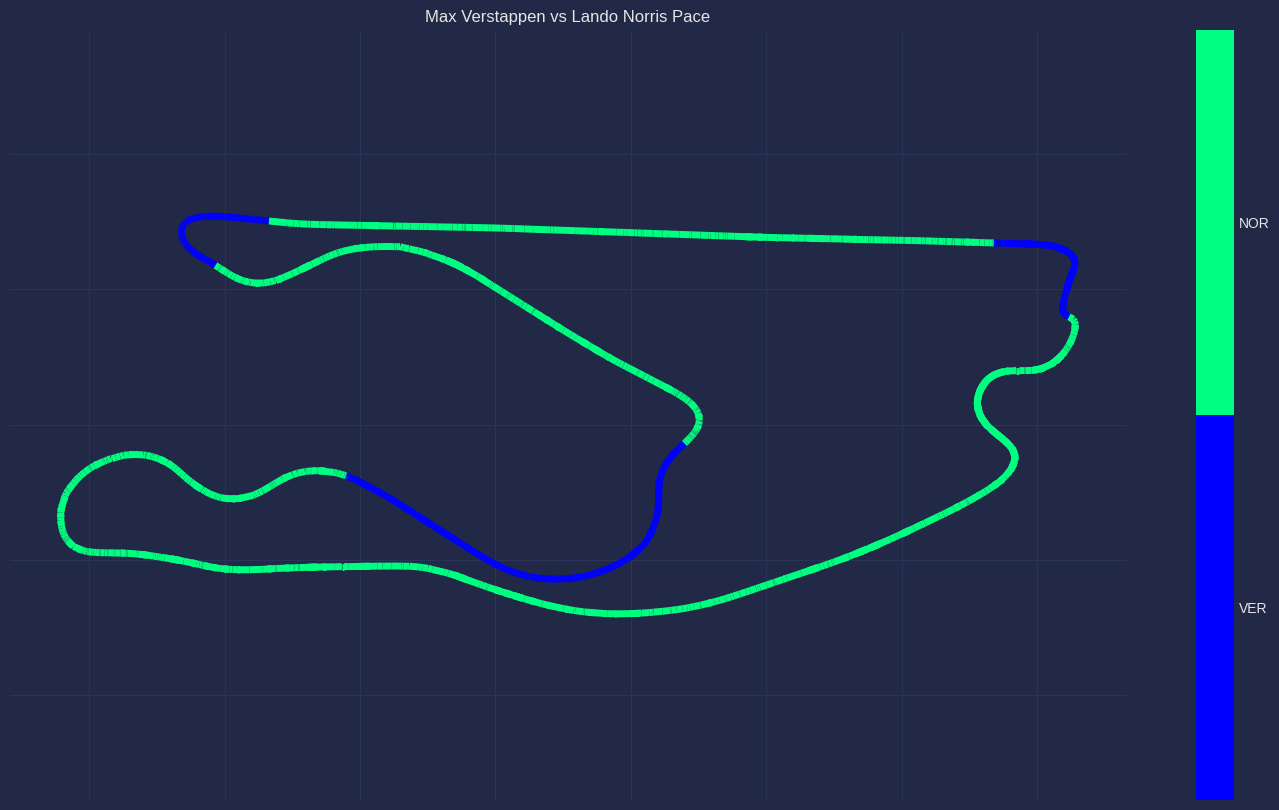

In [75]:
x = np.array(telemetry['X'].values)
y = np.array(telemetry['Y'].values)

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
fastest_driver_array = telemetry['Fastest_driver_int'].to_numpy().astype(float)

cmap = plt.get_cmap('winter', 2)  # Create a colormap with 2 colors
lc_comp = LineCollection(segments, norm=plt.Normalize(1, cmap.N+1), cmap=cmap)
lc_comp.set_array(fastest_driver_array)
lc_comp.set_linewidth(5)

plt.rcParams['figure.figsize'] = [18, 10]
plt.gca().add_collection(lc_comp)
plt.axis('equal')
plt.tick_params(labelleft=False, left=False, labelbottom=False, bottom=False)

cbar = plt.colorbar(mappable=lc_comp, boundaries=[1, 2, 3])
cbar.set_ticks([1.5, 2.5])
cbar.set_ticklabels(['VER', 'NOR'])
plt.title("Max Verstappen vs Lando Norris Pace")
plt.show()
